# Детекция трафика сервисов автоматизированного сбора данных

**Задача.** По событиям внутри суточного окна присвоить каждой `cookie_id` оценку
от 0 до 1: чем выше, тем вероятнее, что за кукой стоит парсер, а не человек.

**Метрика.** `P@R>=0.7` — максимальный precision среди всех порогов, при которых
recall не ниже 0.70. Считается по кукам, не по событиям.

**Результат.**

| Модель | P@R>=0.7 (OOF) |
|---|---|
| Константа (доля ботов в train) | 0.081 |
| Baseline: 2 признака + RandomForest | 0.111 |
| Только поведенческие признаки | 0.798 |
| Все признаки, кроме построенных на метках прошлых дней | 0.797 |
| **Финальная модель: blend LightGBM + XGBoost + CatBoost** | **0.8875** |

---

## Как читать этот notebook

Он самодостаточен: весь код лежит внутри, внешних модулей нет. Порядок разделов
повторяет порядок работы над задачей.

| Раздел | О чём |
|---|---|
| 1 | Окружение и фиксация random seed |
| 2 | Метрика задачи, реализованная ровно по условию |
| 3 | Загрузка данных, окно наблюдения и главная ловушка датасета |
| 4 | EDA: чем поток парсера отличается от человеческого |
| 5 | Baseline |
| 6 | Feature engineering — основная часть решения |
| 7 | Схема валидации и вклад каждого блока признаков |
| 8 | Отбор признаков: фильтр по drift между train и test |
| 9 | Финальная модель: blend трёх градиентных бустингов |
| 10 | Сколько ещё можно выжать из этих данных |
| 11 | Обучение на полном train и запись `submission.csv` |
| 12 | Ограничения модели |

**Состав папки**

```
solution.ipynb      этот notebook: data -> features -> model -> submission.csv
data/               выданный датасет: train.csv, test.csv, events.csv.gz
submission.csv      предсказания для data/test.csv (получены этим notebook)
models/             веса девяти обученных бустингов + список признаков (раздел 11)
requirements.txt    версии библиотек, Python 3.12.3
README.md           краткое описание подхода
```

**Запуск.** `pip install -r requirements.txt`, затем выполнить notebook целиком
(`Run All`). Полный прогон с нуля — около 30 минут на 8 ядрах: сборка признаков
занимает минуту, остальное — обучение. Матрицы признаков кэшируются в `cache/`, а
веса финальных моделей — в `models/`, поэтому повторный прогон занимает около
10 минут (заново считается только ablation-таблица раздела 7). Вся случайность
зафиксирована, результат воспроизводится побитово.

Notebook сохранён вместе с выводом — его можно читать, не запуская.

## 1. Окружение и воспроизводимость

Никаких внешних API и языковых моделей. Только открытые библиотеки, всё считается
локально. Все источники случайности зафиксированы:

* `SEED = 42` — разбиения на fold'ы и bootstrap;
* `MODEL_SEEDS = [11, 22, 33]` — три seed'а на каждый бустинг.

Мы усредняем предсказания по трём seed'ам, чтобы итог не зависел от одного удачного
или неудачного запуска. Потому что метрика чувствительна только к порядку кук вблизи
рабочего порога, а bagging и случайный отбор признаков внутри бустинга меняют этот
порядок от seed'а к seed'у. Порядок величины разброса видно в разделе 7.3: колонка
`std` показывает, насколько метрика расходится всего лишь между двумя раскладками
дней по fold'ам.

In [1]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 80)

SEED = 42
MODEL_SEEDS = [11, 22, 33]

DATA_DIR = Path('data')
CACHE_DIR = Path('cache')            # промежуточные матрицы признаков, пересобираются из data/
MODELS_DIR = Path('models')          # веса обученных бустингов, часть сабмита
CACHE_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
SUBMISSION_PATH = Path('submission.csv')

# Оформление графиков: один стиль на весь notebook.
C_HUMAN, C_BOT, C_INK = '#2a78d6', '#eb6834', '#52514e'
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

import lightgbm, xgboost, catboost, sklearn, scipy, sys
print('python     ', sys.version.split()[0])
for m in (np, pd, scipy, sklearn, lightgbm, xgboost, catboost):
    print(f'{m.__name__:<11}', m.__version__)

python      3.12.3
numpy       2.4.4
pandas      3.0.3
scipy       1.17.1
sklearn     1.8.0
lightgbm    4.7.0
xgboost     3.4.1
catboost    1.2.10


## 2. Метрика задачи

Тут приведена реализация расчёта метрики качества модели $P@R_{>=0.7}$, выданная
авторами задачи (файл `metric.py` из условия), и её самопроверка на примерах оттуда
же.

In [2]:
TARGET_RECALL = 0.70


def pr_curve(y_true, score):
    """(precision, recall) в точках на границах групп одинакового score."""
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    n_pos = int(y_true.sum())
    if n_pos == 0:
        return np.array([]), np.array([])

    order = np.argsort(-score, kind='mergesort')
    y, s = y_true[order], score[order]

    tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]        # последняя строка каждой группы равных score
    return tp[ends] / k[ends], tp[ends] / n_pos


def precision_at_recall(y_true, score, recall=TARGET_RECALL):
    """Основная метрика: максимальный precision среди порогов с recall >= recall."""
    prec, rec = pr_curve(y_true, score)
    if len(prec) == 0:
        return float('nan')
    ok = rec >= recall
    return float(prec[ok].max()) if ok.any() else 0.0


def recall_at_fpr(y_true, score, fpr=0.01):
    """Диагностика: какую долю ботов ловим, задев не более fpr доли людей."""
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    n_pos, n_neg = int(y_true.sum()), int((1 - y_true).sum())
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    order = np.argsort(-score, kind='mergesort')
    y, s = y_true[order], score[order]
    ends = np.r_[s[1:] != s[:-1], True]
    tp, fp = np.cumsum(y)[ends], np.cumsum(1 - y)[ends]
    allowed = fp <= fpr * n_neg
    return float(tp[allowed].max() / n_pos) if allowed.any() else 0.0


# Самопроверка на примерах из условия.
assert precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]) == 0.8   # максимум, а не первая точка
assert precision_at_recall([1, 1, 0, 0], [0.5] * 4) == 0.5            # группа равных score
assert precision_at_recall([0, 0, 1, 1], [0.5] * 4) == 0.5            # порядок строк не влияет
print('метрика: самопроверка пройдена')

метрика: самопроверка пройдена


## 3. Данные и окно наблюдения

Три файла:

* `train.csv` / `test.csv` — по одной строке на `cookie_id`: когда кука создана,
  границы суточного окна наблюдения и `target` (только в train);
* `events.csv.gz` — события этих кук: тип, платформа, User-Agent, объявление и его
  рубрика/город, поисковый запрос и страница выдачи, координаты курсора.

Готовых поведенческих признаков нет — их нужно собрать из событий самостоятельно.

### 3.1 Правило причинности, на котором построено всё решение

Условие требует: признаки должны быть доступны на момент `window_end_ts`. Окно у
каждой куки — ровно сутки, выровненные по полуночи. Отсюда следует, что на момент
конца окна дня `D` легально известны:

| Источник | Доступен? | Почему |
|---|---|---|
| собственные события куки внутри окна | да | это и есть вход задачи |
| **события чужих кук того же дня `D`** | **да** | день `D` полностью закрыт к моменту `D+1` |
| **разметка всех дней раньше `D`** | **да** | эти куки уже размечены |
| любые события позже `window_end_ts` | нет | будущее |

Две строки, выделенные жирным, — самое ценное в задаче. Они открывают два блока
признаков, которые дают основной прирост качества:

* **co-visitation** — несколько кук одного сервиса за сутки обходят один и тот же
  пул объявлений;
* **label propagation** — объявление, которое в прошлые дни уже трогали известные
  боты, компрометирует того, кто смотрит его сегодня.

Фильтр `window_start_ts <= event_ts < window_end_ts` применяется один раз на входе
pipeline, до любых агрегатов. Всё, что позже конца окна, дальше не попадает вообще.

In [3]:
DATE_COLS = ['cookie_created_at', 'window_start_ts', 'window_end_ts']


def load_raw(data_dir=DATA_DIR):
    """train.csv, test.csv, events.csv.gz как есть."""
    train = pd.read_csv(data_dir / 'train.csv', parse_dates=DATE_COLS)
    test = pd.read_csv(data_dir / 'test.csv', parse_dates=DATE_COLS)
    events = pd.read_csv(data_dir / 'events.csv.gz', parse_dates=['event_ts'])
    return train, test, events


def events_in_window(events, meta):
    """События строго внутри окна наблюдения, отсортированные по куке и времени."""
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
                      on='cookie_id', how='inner')
    ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]
    return ev.sort_values(['cookie_id', 'event_ts'], kind='mergesort').reset_index(drop=True)


def prepare(data_dir=DATA_DIR):
    """Метаданные всех кук (train + test) и события, отсечённые по окну."""
    train, test, events = load_raw(data_dir)
    meta = pd.concat([train.drop(columns=['target']), test], ignore_index=True)
    ev_all = events_in_window(events, meta)
    ev_all['day'] = ev_all.window_start_ts          # окно = календарные сутки
    return train, test, events, ev_all


t0 = time.time()
train, test, events_raw, ev_all = prepare()
y = train.target.to_numpy()
days = train.window_start_ts.to_numpy()             # день окна = группа для валидации

print(f'загрузка и отсечение по окну: {time.time() - t0:.0f} c')
print(f'train: {len(train)} кук, {int(y.sum())} ботов ({y.mean():.1%})')
print(f'test:  {len(test)} кук')
print(f'события: {len(events_raw)} всего -> {len(ev_all)} внутри окна')
print(f'train дни: {pd.Timestamp(days.min()).date()} .. {pd.Timestamp(days.max()).date()} '
      f'({len(np.unique(days))} дней)')
print(f'test  дни: {test.window_start_ts.min().date()} .. {test.window_start_ts.max().date()} '
      f'({test.window_start_ts.nunique()} дней) — строго позже train')

загрузка и отсечение по окну: 2 c
train: 11091 кук, 899 ботов (8.1%)
test:  4909 кук
события: 328905 всего -> 288126 внутри окна
train дни: 2026-04-06 .. 2026-04-19 (14 дней)
test  дни: 2026-04-20 .. 2026-04-26 (7 дней) — строго позже train


### 3.2 Проверка качества данных

Прежде чем строить признаки, смотрим на целостность: дубликаты, пропуски, состав
категориальных полей и — главное — события, вылезающие за границу окна.

In [4]:
def quality_report(train, test, events, ev_all):
    """Сводка по целостности данных."""
    meta = pd.concat([train.drop(columns=['target']), test], ignore_index=True)
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    post = ev.event_ts >= ev.window_end_ts
    is_train = ev.cookie_id.isin(set(train.cookie_id))
    rows = [
        ('кук в train / test', f'{len(train)} / {len(test)}'),
        ('пересечение cookie_id между train и test', len(set(train.cookie_id) & set(test.cookie_id))),
        ('дубликаты cookie_id', int(train.cookie_id.duplicated().sum()
                                    + test.cookie_id.duplicated().sum())),
        ('доля ботов в train', round(train.target.mean(), 4)),
        ('длина окна наблюдения', str((train.window_end_ts - train.window_start_ts).unique())),
        ('событий всего', len(events)),
        ('событий внутри окна', len(ev_all)),
        ('событий ПОСЛЕ конца окна', int(post.sum())),
        ('   из них у train-кук', int((post & is_train).sum())),
        ('   из них у test-кук', int((post & ~is_train).sum())),
        ('полных дубликатов строк событий', int(events.duplicated().sum())),
        ('событий captcha_shown внутри окна', int((ev_all.event_name == 'captcha_shown').sum())),
        ('уникальных user_agent', events.user_agent.nunique()),
        ('вариантов написания platform', events.platform.nunique()),
        ('вариантов platform после lower()', events.platform.str.lower().nunique()),
    ]
    return pd.DataFrame(rows, columns=['показатель', 'значение'])


quality_report(train, test, events_raw, ev_all)

,показатель,значение
0,кук в train / test,11091 / 4909
1,пересечение cookie_id между train и test,0
2,дубликаты cookie_id,0
3,доля ботов в train,0.0811
4,длина окна наблюдения,"<TimedeltaArray>\n['1 days']\nLength: 1, dtype: timedelta64[us]"
5,событий всего,328905
6,событий внутри окна,288126
7,событий ПОСЛЕ конца окна,40779
8,из них у train-кук,40779
9,из них у test-кук,0


### 3.3 Главная ловушка датасета: события после конца окна

В `events.csv.gz` лежат 40 779 событий позже `window_end_ts`, и **все они принадлежат
train-кукам** — в тесте таких нет ни одного. У ботов их в среднем 22 на куку, у людей 2.

Признак, построенный на них, выглядит на train почти идеальным разделителем, а на
тесте окажется пустым столбцом. Это классическая data leakage: модель обучится на
артефакте выгрузки, а не на поведении.

Сюда же попала вся капча целиком: 7 928 событий `captcha_shown`, и **внутри окна их
ноль**. То есть капча в этой задаче — не сигнал, а метка того, что кука лежит в train.

График ниже показывает обе стороны ловушки: слева — что post-window события есть
только в train, справа — насколько «хорошо» они делят классы.

Отсюда решение: фильтр по окну стоит на входе pipeline (см. `events_in_window` выше),
а `captcha_shown` после фильтра становится константным нулём и автоматически
выбрасывается отбором признаков в разделе 8.

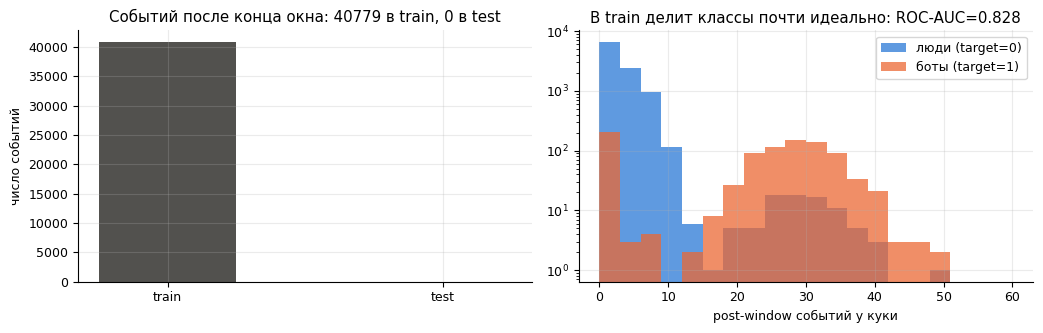

в среднем post-window событий: боты 21.8, люди 2.1
captcha_shown: 7928 событий всего, 0 внутри окна


1662

In [5]:
meta_all = pd.concat([train.drop(columns=['target']), test], ignore_index=True)
_ev = events_raw.merge(meta_all[['cookie_id', 'window_end_ts']], on='cookie_id')
_post = _ev[_ev.event_ts >= _ev.window_end_ts]

n_post = _post.groupby('cookie_id').size()
tr_post = n_post.reindex(train.cookie_id).fillna(0).to_numpy()
te_post = n_post.reindex(test.cookie_id).fillna(0).to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].bar(['train', 'test'], [tr_post.sum(), te_post.sum()], color=[C_INK, C_HUMAN], width=0.5)
ax[0].set_title(f'Событий после конца окна: {int(tr_post.sum())} в train, '
                f'{int(te_post.sum())} в test')
ax[0].set_ylabel('число событий')

bins = np.arange(0, 61, 3)
ax[1].hist(tr_post[y == 0], bins=bins, color=C_HUMAN, alpha=0.75, label='люди (target=0)')
ax[1].hist(tr_post[y == 1], bins=bins, color=C_BOT, alpha=0.75, label='боты (target=1)')
ax[1].set_yscale('log')
ax[1].set_xlabel('post-window событий у куки')
ax[1].set_title(f'В train делит классы почти идеально: '
                f'ROC-AUC={roc_auc_score(y, tr_post):.3f}')
ax[1].legend()
plt.tight_layout(); plt.show()

print(f'в среднем post-window событий: боты {tr_post[y == 1].mean():.1f}, '
      f'люди {tr_post[y == 0].mean():.1f}')
print(f'captcha_shown: {int((events_raw.event_name == "captcha_shown").sum())} событий всего, '
      f'{int((ev_all.event_name == "captcha_shown").sum())} внутри окна')
del _ev, _post
gc.collect()

## 4. EDA: чем поток парсера отличается от человеческого

Смотрим на данные до того, как строить признаки, — чтобы признаки были ответом на
конкретное наблюдение, а не перебором агрегатов. Ниже три наблюдения, которые
определили состав блоков признаков в разделе 6.

### 4.1 Ритм событий

У человека пауза между действиями — случайная величина с тяжёлым хвостом: посмотрел,
отвлёкся, вернулся. У парсера между запросами стоит фиксированная задержка, поэтому
интервалы собираются в узкую полосу коротких значений.

Отсюда признаки: квантили интервала, коэффициент вариации, доли интервалов короче
1/2/3/5/10/20/30/60/120 секунд, доля самого частого значения интервала,
автокорреляция интервалов.

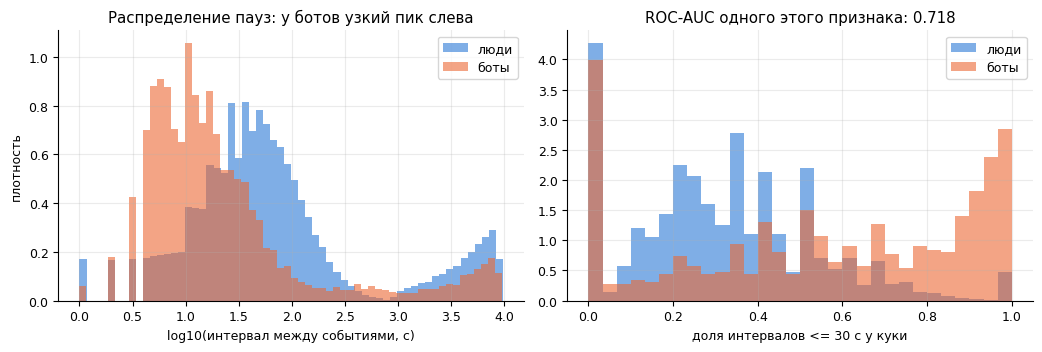

In [6]:
e = ev_all.sort_values(['cookie_id', 'event_ts']).copy()
e['dt'] = e.groupby('cookie_id').event_ts.diff().dt.total_seconds()
e['t'] = e.cookie_id.map(train.set_index('cookie_id').target)
d = e.dropna(subset=['dt', 't'])

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
for cls, col, nm in [(0, C_HUMAN, 'люди'), (1, C_BOT, 'боты')]:
    v = d.loc[d.t == cls, 'dt']
    ax[0].hist(np.log10(v[v > 0]), bins=60, density=True, alpha=0.6, color=col, label=nm)
ax[0].set_xlabel('log10(интервал между событиями, с)')
ax[0].set_ylabel('плотность')
ax[0].set_title('Распределение пауз: у ботов узкий пик слева')
ax[0].legend()

share30 = d.assign(f=d.dt <= 30).groupby(['cookie_id']).agg(f=('f', 'mean'), t=('t', 'first'))
ax[1].hist(share30.loc[share30.t == 0, 'f'], bins=30, density=True, alpha=0.6,
           color=C_HUMAN, label='люди')
ax[1].hist(share30.loc[share30.t == 1, 'f'], bins=30, density=True, alpha=0.6,
           color=C_BOT, label='боты')
ax[1].set_xlabel('доля интервалов <= 30 с у куки')
ax[1].set_title(f'ROC-AUC одного этого признака: '
                f'{roc_auc_score(share30.t, share30.f):.3f}')
ax[1].legend()
plt.tight_layout(); plt.show()

### 4.2 Курсор как биометрия

`pointer_x` / `pointer_y` заполнены только для `desktop` / `web` и только примерно
в 60% их событий — это 36% всех кук. Зато там, где координаты есть, они дают
сильнейший одиночный сигнал во всей задаче: эмулятор мыши двигается короткими
шагами внутри маленького прямоугольника, человек — длинными и по всему экрану.

Важно: покрытие всего 36%, поэтому в одиночку курсор задачу не решает. Именно
поэтому основной вес в решении лежит на признаках связей между куками (раздел 6.2),
которые есть у всех.

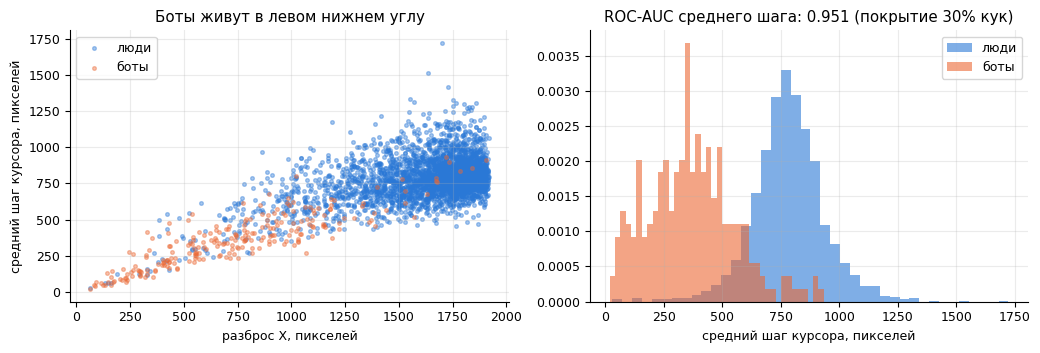

31691

In [7]:
p = e[e.pointer_x.notna()].copy()
p['dist'] = np.hypot(p.groupby('cookie_id').pointer_x.diff(),
                     p.groupby('cookie_id').pointer_y.diff())
agg = p.groupby('cookie_id').agg(x_range=('pointer_x', lambda s: s.max() - s.min()),
                                 step=('dist', 'mean'), n=('pointer_x', 'size'))
agg['t'] = agg.index.map(train.set_index('cookie_id').target)
agg = agg[(agg.n >= 5) & agg.t.notna()]

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
for cls, col, nm in [(0, C_HUMAN, 'люди'), (1, C_BOT, 'боты')]:
    s = agg[agg.t == cls]
    ax[0].scatter(s.x_range, s.step, s=7, alpha=0.4, color=col, label=nm)
ax[0].set_xlabel('разброс X, пикселей'); ax[0].set_ylabel('средний шаг курсора, пикселей')
ax[0].set_title('Боты живут в левом нижнем углу'); ax[0].legend()

ax[1].hist(agg.loc[agg.t == 0, 'step'], bins=40, density=True, alpha=0.6,
           color=C_HUMAN, label='люди')
ax[1].hist(agg.loc[agg.t == 1, 'step'], bins=40, density=True, alpha=0.6,
           color=C_BOT, label='боты')
ax[1].set_xlabel('средний шаг курсора, пикселей')
ax[1].set_title(f'ROC-AUC среднего шага: {roc_auc_score(agg.t, -agg.step):.3f} '
                f'(покрытие {len(agg) / len(train):.0%} кук)')
ax[1].legend()
plt.tight_layout(); plt.show()
del p, agg
gc.collect()

### 4.3 Боты ходят по одному и тому же пулу объявлений

Проверяем гипотезу, на которой держатся два самых сильных блока признаков: сервис
сбора данных обходит устойчивый набор объявлений, а не случайные карточки.

Измерение: берём объявления, которых в первую неделю касались боты, и смотрим, во
сколько раз чаще их касаются боты во вторую неделю по сравнению с людьми. Это
**lift** — если он около 1, гипотеза ложная и признаки на метках работать не будут.

Дополнительно смотрим, не затухает ли lift со временем: признаки на метках прошлых
дней имеют смысл только если пул объявлений доживает до тестовой недели.

пул "ботовых" объявлений первой недели: 4754 шт.
доля событий по нему во вторую неделю: боты 0.478, люди 0.086  ->  lift 5.6x


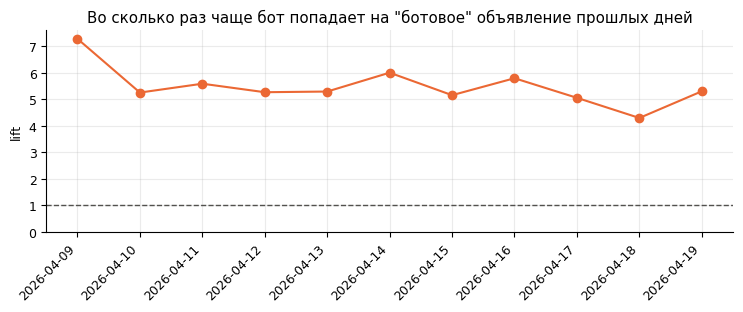

затухания за 11 дней наблюдения нет — признак доживёт до тестовой недели


In [8]:
iv = ev_all[ev_all.item_id.notna()][['cookie_id', 'item_id', 'day']].drop_duplicates()
iv['t'] = iv.cookie_id.map(train.set_index('cookie_id').target)

all_days = np.array(sorted(pd.unique(train.window_start_ts)))
first_half, second_half = set(all_days[:7]), set(all_days[7:])

bot_pool = set(iv[(iv.t == 1) & iv.day.isin(first_half)].item_id)
late = iv[iv.day.isin(second_half) & iv.t.notna()]
hit = late.assign(f=late.item_id.isin(bot_pool)).groupby('cookie_id').agg(
    f=('f', 'mean'), t=('t', 'first'))
lift = hit[hit.t == 1].f.mean() / hit[hit.t == 0].f.mean()
print(f'пул "ботовых" объявлений первой недели: {len(bot_pool)} шт.')
print(f'доля событий по нему во вторую неделю: боты {hit[hit.t == 1].f.mean():.3f}, '
      f'люди {hit[hit.t == 0].f.mean():.3f}  ->  lift {lift:.1f}x')

rows = []
for lag_day in all_days[3:]:
    past = set(iv[(iv.t == 1) & (iv.day < lag_day)].item_id)
    cur = iv[(iv.day == lag_day) & iv.t.notna()]
    h = cur.assign(f=cur.item_id.isin(past)).groupby('cookie_id').agg(
        f=('f', 'mean'), t=('t', 'first'))
    rows.append((pd.Timestamp(lag_day).date(), h[h.t == 1].f.mean(), h[h.t == 0].f.mean()))
lift_df = pd.DataFrame(rows, columns=['день', 'боты', 'люди'])
lift_df['lift'] = lift_df['боты'] / lift_df['люди']

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(lift_df['день'].astype(str), lift_df['lift'], 'o-', color=C_BOT)
ax.axhline(1, color=C_INK, lw=1, ls='--')
ax.set_ylabel('lift'); ax.set_ylim(0, None)
ax.set_title('Во сколько раз чаще бот попадает на "ботовое" объявление прошлых дней')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
print('затухания за 11 дней наблюдения нет — признак доживёт до тестовой недели')

### 4.4 Остальные наблюдения, вошедшие в признаки

* **География против рубрики.** Парсер обходит одну рубрику по многим городам;
  человек сидит в своём городе и смотрит разное. Отсюда `loc_per_cat`,
  энтропии рубрик и городов, доля топ-1 значения.
* **Глубина выдачи.** Человек почти не уходит дальше 2–3 страницы поиска, обходчик
  листает подряд до конца. Отсюда `page_max`, доли страниц >= 3/5/10, доля шагов
  «страница +1 внутри того же запроса».
* **Воронка контактов.** У сервиса, выгружающего контакты, доля `contact_phone_show`
  на просмотр карточки заметно выше человеческой. Отсюда блок `ratio_*_per_view`.
* **Повторы запросов.** Парсер гоняет один и тот же запрос — отсюда
  `query_repeat_ratio` и `same_query_share`.
* **Технический шум, который сигнала не несёт:** `platform` приходит в четырёх
  регистрах (`WEB`, `Web`, `web`, `iphone`/`ios`), есть 4 863 полностью дублирующиеся
  строки событий. Регистр мы нормализуем, дубликаты оставляем как есть, но заводим
  на них признак-счётчик — проверка показала, что самостоятельного сигнала в них нет.

## 5. Baseline

Отправная точка, с которой сравнивается всё остальное: два очевидных агрегата
(сколько событий и сколько разных объявлений) и RandomForest.

Одно отличие от наивного варианта: валидация сразу честная — fold'ы нарезаются
по календарным дням (почему именно так — раздел 7), а метрика берётся из раздела 2.

Baseline нужен, чтобы понимать цену feature engineering: если 380 признаков дают
столько же, сколько два, работа была напрасной.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold

base = ev_all[ev_all.cookie_id.isin(set(train.cookie_id))].groupby('cookie_id').agg(
    n_events=('event_ts', 'size'), n_items=('item_id', 'nunique'))
X_base = base.reindex(train.cookie_id).fillna(0).to_numpy()

oof_base = np.zeros(len(y))
for tr_idx, va_idx in GroupKFold(n_splits=5).split(X_base, y, groups=days):
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                               random_state=SEED, n_jobs=-1)
    m.fit(X_base[tr_idx], y[tr_idx])
    oof_base[va_idx] = m.predict_proba(X_base[va_idx])[:, 1]

print(f'константа (все score равны):  P@R>=0.7 = {y.mean():.4f}')
print(f'baseline (2 признака, RF):    P@R>=0.7 = {precision_at_recall(y, oof_base):.4f}   '
      f'ROC-AUC = {roc_auc_score(y, oof_base):.4f}')

константа (все score равны):  P@R>=0.7 = 0.0811
baseline (2 признака, RF):    P@R>=0.7 = 0.1108   ROC-AUC = 0.6465


## 6. Feature engineering

Готовых поведенческих признаков в задаче нет, поэтому это основная часть решения.
Всего собирается **379 признаков в четырёх блоках**; каждый блок отвечает на свой
вопрос о куке.

| Блок | Признаков | Вопрос, на который отвечает | Примеры |
|---|---|---|---|
| `behavior` (6.1) | 263 | как эта кука вела себя внутри своего окна | `dt_share_le30`, `ptr_dist_mean`, `page_max`, `loc_per_cat`, `ratio_contact_per_view` |
| `timing` (6.2) | 67 | как она соотносится с другими куками и с разметкой прошлых дней | `dti_std`, `cov_inter_sum_norm`, `lp_hit_share`, `te_user_agent_mean` |
| `cookie` (6.3) | 16 | как и когда была создана сама кука | `cookie_age_days`, `created_nb_600s` |
| `sequence` (6.4) | 33 | насколько правдоподобна её цепочка событий и плотно ли она выкачивает каталог | `llr_bi_mean`, `qcov_pages_max`, `lpr_ratio_mean` |

Два правила, общие для всех блоков:

1. **Пропуски не заполняются нулями.** «Курсора нет вообще» (мобильная кука) и
   «курсор в углу экрана» — разные состояния. Градиентный бустинг отправляет `NaN`
   в отдельную ветку дерева, а `fillna(0)` склеил бы эти два состояния в одно.
2. **Категориальные поля не кодируются напрямую.** `platform`, `user_agent`, рубрика
   и город сворачиваются в доли, энтропии и сглаженные target encoding по прошлым
   дням. One-hot по 148 User-Agent'ам дал бы разреженную матрицу и переобучение на
   редкие значения.

### 6.1 Блок `behavior` — поведение куки внутри окна

Всё считается только по событиям внутри окна плюс метаданные куки. Группы признаков:

| Группа | Гипотеза |
|---|---|
| объём и состав событий, биграммы переходов | у парсера вырожденный сценарий: `item_view -> item_view`, без фото и избранного |
| уникальности и энтропии (объявления, рубрики, города, запросы) | обходчик берёт одну рубрику по многим городам |
| тайминги и всплески активности | фиксированная задержка между запросами |
| сессии (разрыв 5 и 30 минут) | у человека несколько коротких сессий, у бота одна длинная |
| покрытие суток и время активности | бот работает ночью и равномерно по суткам |
| пагинация выдачи | человек не листает до 10-й страницы |
| курсор | эмулятор мыши: короткие шаги в маленьком прямоугольнике |
| платформа и User-Agent | несогласованность UA и platform, смена UA внутри окна, флаги `curl` / `Scrapy` / `Headless` |
| популярность контента за день | бот идёт по горячему пулу, который в этот день трогают многие |
| воронка контактов | выгрузка телефонов даёт аномальную долю контактных действий |

Начнём со вспомогательных функций.

In [10]:
EVENT_NAMES = ['search_results_view', 'item_view', 'photo_swipe', 'seller_page_view',
               'contact_phone_show', 'contact_chat_open', 'contact_message_sent',
               'favorite_add', 'login', 'captcha_shown']


def _grouped_entropy(df, key, col):
    """Энтропия распределения значений col внутри каждой группы key.

    Через groupby, без apply: на 300k строк это разница между секундой и минутой.
    """
    c = df.groupby([key, col], observed=True).size().rename('c').reset_index()
    tot = c.groupby(key).c.transform('sum')
    p = c.c / tot
    c['h'] = -p * np.log(p)
    return c.groupby(key).h.sum()


def _grouped_top1(df, key, col):
    """Доля самого частого значения col внутри группы (мера концентрации)."""
    c = df.groupby([key, col], observed=True).size().rename('c').reset_index()
    tot = c.groupby(key).c.transform('sum')
    return (c.c / tot).groupby(c[key]).max()


def _qstats(g, col, prefix, qs=(0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0)):
    """Набор квантилей + среднее и стандартное отклонение для одной величины."""
    out = {}
    for q in qs:
        out[f'{prefix}_q{int(q * 100):03d}'] = g[col].quantile(q)
    out[f'{prefix}_mean'] = g[col].mean()
    out[f'{prefix}_std'] = g[col].std()
    return pd.DataFrame(out)

**Разбор User-Agent.** Уникальных UA всего 148, поэтому разбираем их один раз в
отдельную таблицу и джойним к событиям — это на два порядка дешевле, чем применять
регулярные выражения к 300 тысячам строк.

Флаги двух видов: прямые улики (`curl/`, `Scrapy`, `python-requests`, `Headless`) и
нейтральные поля для сверки — семейство браузера, ОС, длина строки, мажорная версия.
Прямые улики в чистом виде задачу не решают (сервисы маскируются под браузер), но в
сочетании с поведением работают. Отдельно считается **несогласованность UA и
platform**: строка говорит «Android», а события приходят с `desktop`.

In [11]:
_UA_PATTERNS = {
    'ua_headless': r'Headless',
    'ua_curl': r'curl/',
    'ua_scrapy': r'Scrapy',
    'ua_python': r'python-(requests|urllib)',
    'ua_nodefetch': r'node-fetch',
    'ua_gohttp': r'Go-http-client',
    'ua_okhttp': r'okhttp',
    'ua_avitoapp': r'^Avito/',
    'ua_mozilla': r'^Mozilla/5\.0',
    'ua_chrome': r'Chrome/',
    'ua_firefox': r'Firefox/',
    'ua_yabrowser': r'YaBrowser/',
    'ua_safari_only': r'Safari/537\.36$',
    'ua_win': r'Windows NT',
    'ua_mac': r'Macintosh',
    'ua_x11linux': r'X11; Linux',
    'ua_android': r'Android',
    'ua_ios': r'iPhone|iPad|CPU iPhone OS',
}


def ua_table(events):
    """Таблица уникальных User-Agent -> флаги и распарсенные поля."""
    ua = pd.DataFrame({'user_agent': events.user_agent.dropna().unique()})
    s = ua.user_agent
    for name, pat in _UA_PATTERNS.items():
        ua[name] = s.str.contains(pat, regex=True, na=False).astype(np.int8)
    # автоматизированный клиент = строка вообще не браузерная
    ua['ua_tool'] = ((ua.ua_curl | ua.ua_scrapy | ua.ua_python
                      | ua.ua_nodefetch | ua.ua_gohttp).astype(np.int8))
    ua['ua_suspicious'] = ((ua.ua_tool | ua.ua_headless).astype(np.int8))
    ua['ua_len'] = s.str.len().astype(np.int16)
    ua['ua_n_tokens'] = s.str.count(r'[ ;()/]').astype(np.int16)
    ver = s.str.extract(r'(?:Chrome|Firefox|Version|Avito)/(\d+)', expand=False)
    ua['ua_major'] = pd.to_numeric(ver, errors='coerce').astype('float32')
    # ОС по строке UA — нужна, чтобы сверить её с полем platform
    ua['ua_os'] = np.select(
        [ua.ua_android.astype(bool), ua.ua_ios.astype(bool),
         (ua.ua_win | ua.ua_mac | ua.ua_x11linux).astype(bool)],
        ['android', 'ios', 'desktop'], default='other')
    return ua


def popularity_tables(ev_all):
    """Дневные счётчики популярности объектов.

    Считаются по дню окна, то есть доступны на момент window_end_ts (см. раздел 3.1).
    """
    d = ev_all.assign(day=ev_all.window_start_ts.values)
    return {
        'item': d.groupby(['day', 'item_id']).size().rename('pop_item'),
        'query': d.groupby(['day', 'search_query']).size().rename('pop_query'),
        'loc': d.groupby(['day', 'item_location']).size().rename('pop_loc'),
        'cat': d.groupby(['day', 'item_category']).size().rename('pop_cat'),
        'ua': d.groupby(['day', 'user_agent']).cookie_id.nunique().rename('pop_ua'),
        # сколько РАЗНЫХ кук трогало объявление в этот день
        'item_cook': d.groupby(['day', 'item_id']).cookie_id.nunique().rename('cook_item'),
    }

Теперь сам builder блока. Функция длинная, но плоская: одна группа признаков — один
блок кода с заголовком-комментарием. Логика нигде не ветвится, поэтому дробить её на
десяток мелких функций было бы хуже для чтения, чем оставить последовательным списком.

In [12]:
def build_behavior_features(meta, ev, uat, pops):
    """meta: cookie_id + границы окон; ev: события этих кук внутри окна (отсортированы)."""
    ev = ev.copy()
    ev['day'] = ev.window_start_ts
    ev['plat'] = ev.platform.str.lower().replace({'iphone': 'ios'})   # нормализация регистра
    ev = ev.merge(uat, on='user_agent', how='left')

    cid = 'cookie_id'
    g = ev.groupby(cid, sort=True)
    idx = pd.Index(sorted(ev[cid].unique()), name=cid)
    F = pd.DataFrame(index=idx)

    # ---------- объём и состав событий
    F['n_events'] = g.size()
    cnt = pd.crosstab(ev[cid], ev.event_name)
    for name in EVENT_NAMES:
        F[f'n_{name}'] = cnt[name].reindex(idx).fillna(0) if name in cnt else 0.0
        F[f'sh_{name}'] = F[f'n_{name}'] / F['n_events']
    F['ev_type_nuniq'] = g.event_name.nunique()
    F['ev_type_entropy'] = _grouped_entropy(ev, cid, 'event_name').reindex(idx).fillna(0)

    # ---------- уникальности и концентрация
    F['item_nuniq'] = g.item_id.nunique()
    F['cat_nuniq'] = g.item_category.nunique()
    F['loc_nuniq'] = g.item_location.nunique()
    F['query_nuniq'] = g.search_query.nunique()
    F['item_per_event'] = F.item_nuniq / F.n_events
    F['loc_per_event'] = F.loc_nuniq / F.n_events
    F['cat_per_event'] = F.cat_nuniq / F.n_events
    F['loc_per_cat'] = F.loc_nuniq / F.cat_nuniq.clip(lower=1)     # «одна рубрика, много городов»
    F['item_repeat_ratio'] = 1 - F.item_nuniq / g.item_id.count().clip(lower=1)
    F['query_repeat_ratio'] = 1 - F.query_nuniq / g.search_query.count().clip(lower=1)

    F['cat_entropy'] = _grouped_entropy(ev.dropna(subset=['item_category']),
                                        cid, 'item_category').reindex(idx).fillna(0)
    F['loc_entropy'] = _grouped_entropy(ev.dropna(subset=['item_location']),
                                        cid, 'item_location').reindex(idx).fillna(0)
    F['cat_top1'] = _grouped_top1(ev.dropna(subset=['item_category']),
                                  cid, 'item_category').reindex(idx)
    F['loc_top1'] = _grouped_top1(ev.dropna(subset=['item_location']),
                                  cid, 'item_location').reindex(idx)
    F['query_top1'] = _grouped_top1(ev.dropna(subset=['search_query']),
                                    cid, 'search_query').reindex(idx)
    cl = ev.dropna(subset=['item_category', 'item_location'])
    F['catloc_nuniq'] = cl.groupby(cid).apply(
        lambda x: len(set(zip(x.item_category, x.item_location))),
        include_groups=False).reindex(idx).fillna(0)
    F['catloc_per_event'] = F.catloc_nuniq / F.n_events

    # ---------- тайминги
    ev['dt'] = g.event_ts.diff().dt.total_seconds()
    d = ev.dropna(subset=['dt'])
    gd = d.groupby(cid)
    F = F.join(_qstats(gd, 'dt', 'dt'))
    F['dt_cv'] = F.dt_std / F.dt_mean.replace(0, np.nan)           # коэффициент вариации
    F['dt_iqr_over_med'] = (F.dt_q075 - F.dt_q025) / (F.dt_q050 + 1e-6)
    F['dt_burstiness'] = (F.dt_std - F.dt_mean) / (F.dt_std + F.dt_mean + 1e-9)
    for x in [1, 2, 3, 5, 10, 20, 30, 60, 120]:
        F[f'dt_share_le{x}'] = d.assign(f=(d.dt <= x)).groupby(cid).f.mean().reindex(idx)
    ld = d.assign(ld=np.log1p(d.dt))
    F['logdt_mean'] = ld.groupby(cid).ld.mean()
    F['logdt_std'] = ld.groupby(cid).ld.std()
    F['dt_nuniq_ratio'] = gd.dt.nunique() / gd.dt.size()           # повторяются ли паузы
    F['dt_mode_share'] = gd.dt.agg(
        lambda s: s.value_counts(normalize=True).iloc[0] if len(s) else np.nan)
    F['dt_acf1'] = gd.dt.agg(lambda s: s.autocorr(1) if len(s) > 3 else np.nan)

    # ---------- сессии: разрыв 5 и 30 минут
    for gap, tag in [(300, '5m'), (1800, '30m')]:
        newsess = (ev.dt > gap) | ev.dt.isna()
        sid = newsess.groupby(ev[cid]).cumsum()
        ses = ev.assign(sid=sid).groupby([cid, 'sid'])
        ssz = ses.size().rename('sz')
        sdur = (ses.event_ts.max() - ses.event_ts.min()).dt.total_seconds().rename('dur')
        s = pd.concat([ssz, sdur], axis=1).reset_index()
        sg = s.groupby(cid)
        F[f'nsess_{tag}'] = sg.size().reindex(idx)
        F[f'sess_sz_mean_{tag}'] = sg.sz.mean().reindex(idx)
        F[f'sess_sz_max_{tag}'] = sg.sz.max().reindex(idx)
        F[f'sess_dur_mean_{tag}'] = sg.dur.mean().reindex(idx)
        F[f'sess_dur_max_{tag}'] = sg.dur.max().reindex(idx)
        F[f'sess_rate_{tag}'] = F[f'sess_sz_mean_{tag}'] / (F[f'sess_dur_mean_{tag}'] + 1)

    # ---------- покрытие суток и время активности
    ev['sec'] = (ev.event_ts - ev.window_start_ts).dt.total_seconds()
    F['first_sec'] = g.sec.min()
    F['last_sec'] = g.sec.max()
    F['span_sec'] = F.last_sec - F.first_sec
    F['span_share'] = F.span_sec / 86400
    F['rate_per_span'] = F.n_events / (F.span_sec + 1)
    ev['hour'] = ev.event_ts.dt.hour
    F['hour_nuniq'] = g.hour.nunique()
    F['hour_entropy'] = _grouped_entropy(ev, cid, 'hour').reindex(idx).fillna(0)
    F['night_share'] = ev.assign(n=ev.hour.isin([0, 1, 2, 3, 4, 5])).groupby(cid).n.mean()
    F['deepnight_share'] = ev.assign(n=ev.hour.isin([1, 2, 3, 4])).groupby(cid).n.mean()
    F['workhour_share'] = ev.assign(n=ev.hour.between(9, 18)).groupby(cid).n.mean()
    F['evening_share'] = ev.assign(n=ev.hour.between(19, 23)).groupby(cid).n.mean()
    F['hour_mean'] = g.hour.mean()
    F['hour_std'] = g.hour.std()
    # всплески: максимум событий в окне 60 / 300 / 3600 секунд
    for w, tag in [(60, '1m'), (300, '5m'), (3600, '1h')]:
        b = ev.assign(b=(ev.sec // w).astype(int)).groupby([cid, 'b']).size()
        F[f'maxburst_{tag}'] = b.groupby(cid).max().reindex(idx)
        F[f'nbins_{tag}'] = b.groupby(cid).size().reindex(idx)
        F[f'burst_share_{tag}'] = F[f'maxburst_{tag}'] / F.n_events

    # ---------- пагинация выдачи
    s = ev[ev.event_name == 'search_results_view']
    sg = s.groupby(cid)
    F['page_max'] = sg.search_page.max().reindex(idx)
    F['page_mean'] = sg.search_page.mean().reindex(idx)
    F['page_q090'] = sg.search_page.quantile(0.9).reindex(idx)
    F['page_sum'] = sg.search_page.sum().reindex(idx)
    F['page_nuniq'] = sg.search_page.nunique().reindex(idx)
    F['pages_per_query'] = (sg.size() / sg.search_query.nunique().clip(lower=1)).reindex(idx)
    for k in [3, 5, 10]:
        F[f'page_share_ge{k}'] = s.assign(f=(s.search_page >= k)).groupby(cid).f.mean().reindex(idx)
    # последовательное листание внутри одного запроса: «страница +1»
    ss = s.copy()
    ss['same_q'] = ss.search_query == ss.groupby(cid).search_query.shift()
    ss['dp'] = ss.search_page - ss.groupby(cid).search_page.shift()
    sq = ss[ss.same_q]
    F['page_step1_share'] = sq.assign(f=(sq.dp == 1)).groupby(cid).f.mean().reindex(idx)
    F['page_step_mean'] = sq.groupby(cid).dp.mean().reindex(idx)
    F['same_query_share'] = ss.groupby(cid).same_q.mean().reindex(idx)
    F['query_len_mean'] = s.groupby(cid).search_query.apply(
        lambda x: x.str.len().mean()).reindex(idx)

    # ---------- курсор
    p = ev[ev.pointer_x.notna()].copy()
    pg = p.groupby(cid)
    F['ptr_share'] = ev.assign(f=ev.pointer_x.notna()).groupby(cid).f.mean()
    desk = ev[ev.plat.isin(['web', 'desktop'])]
    F['ptr_share_desk'] = desk.assign(f=desk.pointer_x.notna()).groupby(cid).f.mean().reindex(idx)
    F['ptr_n'] = pg.size().reindex(idx).fillna(0)
    for c in ['pointer_x', 'pointer_y']:
        t = c[-1]
        F[f'ptr_{t}_mean'] = pg[c].mean().reindex(idx)
        F[f'ptr_{t}_std'] = pg[c].std().reindex(idx)
        F[f'ptr_{t}_min'] = pg[c].min().reindex(idx)
        F[f'ptr_{t}_max'] = pg[c].max().reindex(idx)
        F[f'ptr_{t}_range'] = F[f'ptr_{t}_max'] - F[f'ptr_{t}_min']
    F['ptr_area'] = F.ptr_x_range * F.ptr_y_range
    F['ptr_aspect'] = F.ptr_x_range / (F.ptr_y_range + 1)
    p['dx'] = pg.pointer_x.diff()
    p['dy'] = pg.pointer_y.diff()
    p['dist'] = np.hypot(p.dx, p.dy)
    pd2 = p.dropna(subset=['dist']).groupby(cid)
    F['ptr_dist_mean'] = pd2.dist.mean().reindex(idx)
    F['ptr_dist_med'] = pd2.dist.median().reindex(idx)
    F['ptr_dist_std'] = pd2.dist.std().reindex(idx)
    F['ptr_dist_max'] = pd2.dist.max().reindex(idx)
    F['ptr_dist_min'] = pd2.dist.min().reindex(idx)
    # координаты, кратные 5 и 10 — след генератора, а не живой руки
    F['ptr_grid10'] = p.assign(f=(p.pointer_x % 10 == 0)).groupby(cid).f.mean().reindex(idx)
    F['ptr_grid5'] = p.assign(f=(p.pointer_x % 5 == 0)).groupby(cid).f.mean().reindex(idx)
    F['ptr_xy_nuniq_ratio'] = (p.groupby(cid).apply(
        lambda x: len(set(zip(x.pointer_x, x.pointer_y))) / len(x),
        include_groups=False)).reindex(idx)

    # ---------- платформа и User-Agent
    F['plat_nuniq'] = g.plat.nunique()
    F['plat_raw_nuniq'] = g.platform.nunique()
    for pl in ['web', 'desktop', 'android', 'ios']:
        F[f'plat_sh_{pl}'] = ev.assign(f=(ev.plat == pl)).groupby(cid).f.mean()
    F['ua_nuniq'] = g.user_agent.nunique()
    for c in list(_UA_PATTERNS) + ['ua_tool', 'ua_suspicious']:
        F[f'{c}_share'] = g[c].mean()
        F[f'{c}_any'] = g[c].max()
    F['ua_len_mean'] = g.ua_len.mean()
    F['ua_major_mean'] = g.ua_major.mean()
    F['ua_ntok_mean'] = g.ua_n_tokens.mean()
    # UA говорит одно, platform другое
    ok = (((ev.plat.isin(['web', 'desktop'])) & (ev.ua_os == 'desktop'))
          | ((ev.plat == 'android') & (ev.ua_os == 'android'))
          | ((ev.plat == 'ios') & (ev.ua_os == 'ios')))
    F['ua_plat_mismatch'] = ev.assign(f=(~ok)).groupby(cid).f.mean()
    # смена UA / платформы по ходу окна
    F['ua_switches'] = ev.assign(
        f=(ev.user_agent != ev.groupby(cid).user_agent.shift())).groupby(cid).f.sum() - 1
    F['plat_switches'] = ev.assign(
        f=(ev.plat != ev.groupby(cid).plat.shift())).groupby(cid).f.sum() - 1

    # ---------- популярность контента за день
    ev = ev.join(pops['item'], on=['day', 'item_id'])
    ev = ev.join(pops['item_cook'], on=['day', 'item_id'])
    ev = ev.join(pops['query'], on=['day', 'search_query'])
    ev = ev.join(pops['loc'], on=['day', 'item_location'])
    ev = ev.join(pops['cat'], on=['day', 'item_category'])
    ev = ev.join(pops['ua'], on=['day', 'user_agent'])
    gg = ev.groupby(cid)
    for c in ['pop_item', 'cook_item', 'pop_query', 'pop_loc', 'pop_cat', 'pop_ua']:
        F[f'{c}_mean'] = gg[c].mean()
        F[f'{c}_med'] = gg[c].median()
        F[f'{c}_max'] = gg[c].max()
    F['pop_item_std'] = gg.pop_item.std()
    F['pop_item_min'] = gg.pop_item.min()
    for k in [8, 12, 16]:
        F[f'pop_item_share_ge{k}'] = ev.assign(f=(ev.pop_item >= k)).groupby(cid).f.mean()

    # ---------- дубликаты событий
    dup = ev.duplicated(subset=[cid, 'event_ts', 'eid', 'item_id'], keep=False)
    F['dup_share'] = ev.assign(f=dup).groupby(cid).f.mean()
    dupfull = ev.duplicated(subset=[cid, 'event_ts', 'eid', 'item_id', 'search_query',
                                    'search_page', 'platform', 'user_agent'], keep=False)
    F['dupfull_share'] = ev.assign(f=dupfull).groupby(cid).f.mean()
    F['dt0_share'] = d.assign(f=(d.dt == 0)).groupby(cid).f.mean()

    # ---------- тип продавца
    F['seller_pro_share'] = ev.assign(f=(ev.seller_type == 'pro')).groupby(cid).f.mean()
    F['seller_na_share'] = ev.assign(f=ev.seller_type.isna()).groupby(cid).f.mean()
    it = ev[ev.item_id.notna()]
    F['seller_pro_share_item'] = it.assign(
        f=(it.seller_type == 'pro')).groupby(cid).f.mean().reindex(idx)

    # ---------- биграммы переходов между типами событий
    ev['prev_ev'] = ev.groupby(cid).event_name.shift()
    bg = ev.dropna(subset=['prev_ev'])
    pair = bg.prev_ev + '>' + bg.event_name
    top_pairs = ['item_view>item_view', 'search_results_view>search_results_view',
                 'item_view>search_results_view', 'search_results_view>item_view',
                 'item_view>photo_swipe', 'photo_swipe>photo_swipe', 'photo_swipe>item_view',
                 'item_view>favorite_add', 'item_view>seller_page_view',
                 'seller_page_view>item_view', 'item_view>contact_phone_show',
                 'seller_page_view>seller_page_view', 'favorite_add>favorite_add',
                 'photo_swipe>favorite_add', 'login>item_view',
                 'contact_chat_open>contact_message_sent',
                 'contact_phone_show>contact_phone_show',
                 'seller_page_view>contact_phone_show', 'item_view>login']
    pv = pd.crosstab(bg[cid], pair, normalize='index')
    for p_ in top_pairs:
        F[f'bg_{p_.replace(">", "__")}'] = pv[p_].reindex(idx).fillna(0) if p_ in pv else 0.0
    F['self_repeat_share'] = bg.assign(
        f=(bg.prev_ev == bg.event_name)).groupby(cid).f.mean().reindex(idx)

    # ---------- воронка контактов
    nv = F.n_item_view.clip(lower=1)
    F['ratio_contact_per_view'] = (F.n_contact_phone_show + F.n_contact_chat_open
                                   + F.n_contact_message_sent) / nv
    F['ratio_phone_per_view'] = F.n_contact_phone_show / nv
    F['ratio_seller_per_view'] = F.n_seller_page_view / nv
    F['ratio_photo_per_view'] = F.n_photo_swipe / nv
    F['ratio_fav_per_view'] = F.n_favorite_add / nv
    F['ratio_view_per_search'] = F.n_item_view / F.n_search_results_view.clip(lower=1)
    F['ratio_item_per_search'] = F.item_nuniq / F.n_search_results_view.clip(lower=1)

    # ---------- порядок обхода объявлений (item_id как число)
    it2 = ev[ev.item_id.notna()].copy()
    it2['d_item'] = it2.groupby(cid).item_id.diff()
    gi = it2.dropna(subset=['d_item']).groupby(cid)
    F['item_diff_pos_share'] = gi.d_item.agg(lambda s: (s > 0).mean()).reindex(idx)
    F['item_diff_abs_med'] = gi.d_item.agg(lambda s: s.abs().median()).reindex(idx)
    F['item_id_std'] = it2.groupby(cid).item_id.std().reindex(idx)

    # ---------- метаданные самой куки
    F = F.reindex(meta.cookie_id.values)
    F.index.name = cid
    m = meta.set_index(cid).reindex(F.index)
    age = (m.window_start_ts - m.cookie_created_at).dt.total_seconds()
    F['cookie_age_days'] = age / 86400
    F['cookie_age_log'] = np.log1p(age / 86400)
    F['cookie_created_hour'] = m.cookie_created_at.dt.hour
    F['cookie_created_dow'] = m.cookie_created_at.dt.dayofweek
    F['cookie_created_night'] = m.cookie_created_at.dt.hour.isin([0, 1, 2, 3, 4, 5]).astype(np.int8)
    F['window_dow'] = m.window_start_ts.dt.dayofweek
    F['window_is_weekend'] = (F.window_dow >= 5).astype(np.int8)
    F['events_per_age_day'] = F.n_events / (F.cookie_age_days + 1)

    # ---------- логарифмы тяжелохвостых счётчиков
    for c in ['n_events', 'item_nuniq', 'loc_nuniq', 'page_sum', 'span_sec', 'maxburst_1h']:
        F[f'log_{c}'] = np.log1p(F[c].astype(float))

    F = F.replace([np.inf, -np.inf], np.nan)
    return F.astype(np.float32)


def build_block_behavior(train, test, events_raw, ev_all):
    """train и test считаются отдельно: внутри блока нет ничего общего между выборками."""
    uat = ua_table(events_raw)
    pops = popularity_tables(ev_all)
    tr_ids, te_ids = set(train.cookie_id), set(test.cookie_id)
    return (build_behavior_features(train, ev_all[ev_all.cookie_id.isin(tr_ids)], uat, pops),
            build_behavior_features(test, ev_all[ev_all.cookie_id.isin(te_ids)], uat, pops))

### 6.2 Блок `timing` — тайминги внутри сессии и связи между куками

Самый важный блок: именно он даёт скачок качества с 0.80 до 0.89. Состоит из
четырёх частей.

**(а) Интервалы внутри сессии.** В блоке `behavior` интервалы считались по всем
событиям подряд, включая паузы «человек ушёл на три часа». Здесь паузы длиннее
10 минут отбрасываются, и остаётся чистый рабочий ритм. Дополнительно — интервал
**после конкретного типа события**: сколько кука «думает» над карточкой против
того, сколько она думает над выдачей. У человека это разные числа, у парсера
одинаковые.

**(б) Согласованность запроса и просмотра.** Человек ищет «айфон» и открывает
карточки из рубрики «телефоны». Обходчик может открывать карточки, никак не
связанные с последним запросом. Признаки `cat_match_query`, `view_has_prev_query`.

**(в) Co-visitation внутри дня.** Здесь используется правило из раздела 3.1: на
момент конца дня `D` доступны события **всех** кук этого дня. Строим разреженную
матрицу «кука × объявление», умножаем её на транспонированную и получаем для каждой
куки: сколько объявлений у неё пересекается с самым похожим соседом, со сколькими
соседями она пересекается вообще, коэффициент Жаккара. Несколько кук одного сервиса
за сутки обходят один пул — у них пересечения кратно выше, чем у случайных людей.

**(г) Историческая популярность объявления** — по всем дням строго раньше дня окна.

Отдельно поясним, почему co-visitation не является leakage: признак не использует
ни одной метки и ни одного события из будущего — только события того же дня, который
к моменту предсказания уже закрыт.

In [13]:
def timing_features(ev):
    """Интервалы внутри сессии (паузы > 10 минут отброшены) и интервалы по типам событий."""
    cid = 'cookie_id'
    g = ev.groupby(cid, sort=True)
    idx = pd.Index(sorted(ev[cid].unique()), name=cid)
    F = pd.DataFrame(index=idx)
    ev = ev.copy()
    ev['dt'] = g.event_ts.diff().dt.total_seconds()
    ev['prev_ev'] = g.event_name.shift()

    ins = ev[ev.dt <= 600]
    gi = ins.groupby(cid)
    F['dti_med'] = gi.dt.median()
    F['dti_mean'] = gi.dt.mean()
    F['dti_std'] = gi.dt.std()
    F['dti_q025'] = gi.dt.quantile(.25)
    F['dti_q075'] = gi.dt.quantile(.75)
    F['dti_q090'] = gi.dt.quantile(.90)
    F['dti_cv'] = F.dti_std / F.dti_mean.replace(0, np.nan)
    F['dti_iqr'] = F.dti_q075 - F.dti_q025
    F['dti_iqr_rel'] = F.dti_iqr / (F.dti_med + 1e-6)
    F['dti_n'] = gi.size().reindex(idx).fillna(0)
    F['dti_share'] = F.dti_n / g.size()
    F['dti_logstd'] = ins.assign(l=np.log1p(ins.dt)).groupby(cid).l.std()
    F['dti_max'] = gi.dt.max()
    F['dti_min'] = gi.dt.min()

    # «сколько кука думает» после события каждого типа
    for nm in ['item_view', 'search_results_view', 'photo_swipe',
               'seller_page_view', 'favorite_add']:
        sub = ev[(ev.prev_ev == nm) & (ev.dt <= 600)]
        gg = sub.groupby(cid)
        F[f'dt_after_{nm}_med'] = gg.dt.median().reindex(idx)
        F[f'dt_after_{nm}_std'] = gg.dt.std().reindex(idx)
    F['dt_view_over_search'] = F.dt_after_item_view_med / (F.dt_after_search_results_view_med + 1e-6)
    return F


def page_features(ev):
    """Глубина выдачи и согласованность «поисковый запрос -> открытая рубрика»."""
    cid = 'cookie_id'
    idx = pd.Index(sorted(ev[cid].unique()), name=cid)
    s = ev[ev.event_name == 'search_results_view']
    g = s.groupby(cid)
    F = pd.DataFrame(index=idx)
    F['page_std'] = g.search_page.std().reindex(idx)
    F['page_q025'] = g.search_page.quantile(.25).reindex(idx)
    F['page1_share'] = s.assign(f=(s.search_page == 1)).groupby(cid).f.mean().reindex(idx)
    F['page_nuniq_ratio'] = (g.search_page.nunique() / g.size()).reindex(idx)
    F['page_range'] = (g.search_page.max() - g.search_page.min()).reindex(idx)

    # какая рубрика чаще всего соответствует данному запросу
    q2cat = s.groupby('search_query').item_category.agg(
        lambda x: x.value_counts().index[0] if len(x.dropna()) else None)
    seq = ev[ev.event_name.isin(['search_results_view', 'item_view'])].copy()
    seq['q'] = seq.search_query.where(seq.event_name == 'search_results_view')
    seq['prev_q'] = seq.groupby(cid).q.ffill()          # последний запрос перед просмотром
    iv = seq[seq.event_name == 'item_view']
    F['cat_match_query'] = iv.assign(
        f=(iv.item_category == iv.prev_q.map(q2cat))).groupby(cid).f.mean().reindex(idx)
    F['view_has_prev_query'] = iv.assign(f=iv.prev_q.notna()).groupby(cid).f.mean().reindex(idx)
    return F


def covisit_day_features(ev_all):
    """Co-visitation внутри дня: пересечения по объявлениям с другими куками того же дня."""
    iv = ev_all[ev_all.item_id.notna()][['cookie_id', 'item_id', 'day']].drop_duplicates()
    parts = []
    for day, sub in iv.groupby('day'):
        cc, uc = pd.factorize(sub.cookie_id)
        ci, _ = pd.factorize(sub.item_id)
        M = coo_matrix((np.ones(len(sub)), (cc, ci)), shape=(len(uc), ci.max() + 1)).tocsr()
        sizes = np.asarray(M.sum(1)).ravel()            # сколько объявлений у куки
        C = (M @ M.T).tocsr()                           # размер пересечения пар кук
        C.setdiag(0); C.eliminate_zeros()
        rows = np.repeat(np.arange(len(sizes)), np.diff(C.indptr))
        jac = C.data / (sizes[rows] + sizes[C.indices] - C.data)     # коэффициент Жаккара
        J = C.copy(); J.data = jac
        nb_hi = np.array([(C.data[C.indptr[i]:C.indptr[i + 1]] >= 3).sum()
                          for i in range(C.shape[0])])
        parts.append(pd.DataFrame({
            'cov_inter_max': np.asarray(C.max(1).todense()).ravel(),
            'cov_inter_sum': np.asarray(C.sum(1)).ravel(),
            'cov_n_nb': np.diff(C.indptr),
            'cov_jac_max': np.asarray(J.max(1).todense()).ravel(),
            'cov_jac_sum': np.asarray(J.sum(1)).ravel(),
            'cov_nb_ge3': nb_hi,
            'cov_size': sizes,
        }, index=uc))
    F = pd.concat(parts)
    F.index.name = 'cookie_id'
    # нормировка на размер: иначе признак измеряет просто активность куки
    F['cov_inter_sum_norm'] = F.cov_inter_sum / F.cov_size.clip(lower=1)
    F['cov_n_nb_norm'] = F.cov_n_nb / F.cov_size.clip(lower=1)
    F['cov_jac_sum_norm'] = F.cov_jac_sum / F.cov_size.clip(lower=1)

    dp = ev_all.groupby(['day', 'item_id']).cookie_id.nunique().rename('c')
    e2 = ev_all[ev_all.item_id.notna()].join(dp, on=['day', 'item_id'])
    gg = e2.groupby('cookie_id')
    F['day_pop_mean'] = gg.c.mean()
    F['day_pop_max'] = gg.c.max()
    F['day_pop_ge3'] = e2.assign(f=(e2.c >= 3)).groupby('cookie_id').f.mean()
    return F


def hist_pop_features(ev_all):
    """Популярность объявления по всем дням строго раньше дня окна."""
    dp = ev_all.groupby(['day', 'item_id']).cookie_id.nunique().rename('c').reset_index()
    day_list = np.array(sorted(ev_all.day.unique()))
    e2 = ev_all[ev_all.item_id.notna()]
    out = []
    for i, D in enumerate(day_list):
        cur = e2[e2.day == D]
        if i == 0:                                      # для первого дня истории ещё нет
            out.append(pd.DataFrame({'h': np.nan}, index=cur.index)
                       .assign(cookie_id=cur.cookie_id.values))
            continue
        prev = dp[dp.day < D].groupby('item_id').c.sum() / i     # нормировка на число дней
        out.append(pd.DataFrame({'h': cur.item_id.map(prev).values,
                                 'cookie_id': cur.cookie_id.values}))
    H = pd.concat(out)
    g = H.groupby('cookie_id')
    return pd.DataFrame({
        'hist_pop_mean': g.h.mean(), 'hist_pop_max': g.h.max(), 'hist_pop_med': g.h.median(),
        'hist_pop_na': H.assign(f=H.h.isna()).groupby('cookie_id').f.mean(),
    })

**(д) Label propagation — распространение меток по контенту.**

Это самый сильный и самый деликатный по корректности блок, поэтому разберём его
отдельно.

*Идея.* Если объявление в прошлые размеченные дни трогали в основном боты, то кука,
которая смотрит его сегодня, скорее всего тоже бот. Считаем для каждой куки, по
скольким её объявлениям были «ботовые касания», какова сглаженная доля ботов среди
прошлых посетителей её объявлений, и то же самое для `user_agent`, города, рубрики и
поискового запроса (сглаженный target encoding).

*Почему это законно.* Разметка всех дней раньше дня окна известна к моменту
предсказания — это прямое следствие правила из раздела 3.1. Для тестовых кук
доступны все 14 размеченных дней train.

*Как не дать train-части подсмотреть собственную метку.* Если для куки дня `D`
считать долю ботов по всем train-дням включая `D`, кука увидит свою же метку через
собственное объявление, метрика на валидации взлетит, а на тесте ничего не будет.
Поэтому используется **leave-one-day-out**: для куки дня `D` берутся метки всех
размеченных дней, **кроме `D`**. Для тестовой куки — все 14 дней. Силы признака это
не меняет (13 дней против 14), а утечки не остаётся.

*Сглаживание.* Доля ботов считается как `(число ботов + prior * alpha) / (всего + alpha)`,
где `prior` — общая доля ботов, `alpha = 6` для объявлений и `20` для категориальных
полей. Без сглаживания объявление с одним-единственным посетителем-ботом давало бы
долю 1.0 и модель училась бы на шуме.

In [14]:
def _te_map(past, col, prior, alpha):
    """Сглаженный target encoding: доля ботов по значению col среди кук прошлых дней."""
    g = past.groupby(col).t.agg(['sum', 'size'])
    return (g['sum'] + prior * alpha) / (g['size'] + alpha)


def label_features(ev_all, labels, train_days):
    """labels: target по cookie_id (только train).

    Для train-дня D источник меток — все размеченные дни кроме D (leave-one-day-out),
    для тестового дня — весь размеченный период.
    """
    prior = float(labels.mean())
    day_list = np.array(sorted(ev_all.day.unique()))

    iv = ev_all[ev_all.item_id.notna()][['cookie_id', 'item_id', 'day']].drop_duplicates()
    iv['t'] = iv.cookie_id.map(labels)

    cat_cols = ['user_agent', 'item_location', 'search_query', 'item_category']
    cats = {c: ev_all[ev_all[c].notna()][['cookie_id', c, 'day']].drop_duplicates()
            for c in cat_cols}
    for c in cat_cols:
        cats[c]['t'] = cats[c].cookie_id.map(labels)

    chunks = []
    for D in day_list:
        if D in train_days:
            mask_past = (iv.day != D) & (iv.day.isin(train_days))     # leave-one-day-out
        else:
            mask_past = iv.day.isin(train_days)                       # весь размеченный период
        past = iv[mask_past & iv.t.notna()]
        cur = iv[iv.day == D]
        if len(past) == 0 or len(cur) == 0:
            continue

        bot = past[past.t == 1].groupby('item_id').size()
        hum = past[past.t == 0].groupby('item_id').size()
        b = cur.item_id.map(bot).fillna(0).values
        h = cur.item_id.map(hum).fillna(0).values
        tmp = cur.assign(b=b, h=h, r=(b + prior * 6) / (b + h + 6),
                         hit=(b > 0), hhit=(h > 0))
        gg = tmp.groupby('cookie_id')
        part = pd.DataFrame({
            'lp_bot_mean': gg.b.mean(), 'lp_bot_max': gg.b.max(), 'lp_bot_sum': gg.b.sum(),
            'lp_ratio_mean': gg.r.mean(), 'lp_ratio_max': gg.r.max(), 'lp_ratio_std': gg.r.std(),
            'lp_hit_share': gg.hit.mean(), 'lp_humhit_share': gg.hhit.mean(),
        })
        part['lp_lift'] = part.lp_hit_share / (part.lp_humhit_share + 0.05)

        for c in cat_cols:
            src = cats[c]
            if D in train_days:
                p = src[(src.day != D) & src.day.isin(train_days) & src.t.notna()]
            else:
                p = src[src.day.isin(train_days) & src.t.notna()]
            m = _te_map(p, c, prior, 20.0)
            cc = src[src.day == D]
            z = cc.assign(r=cc[c].map(m).fillna(prior)).groupby('cookie_id').r
            part[f'te_{c}_mean'] = z.mean()
            part[f'te_{c}_max'] = z.max()
        chunks.append(part)

    F = pd.concat(chunks)
    F.index.name = 'cookie_id'
    return F


def build_block_timing(train, test, ev_all):
    labels = train.set_index('cookie_id').target.astype(float)
    train_days = set(pd.unique(train.window_start_ts))

    # (а) и (б) считаются по каждой выборке отдельно
    parts = []
    for ids in (set(train.cookie_id), set(test.cookie_id)):
        sub = ev_all[ev_all.cookie_id.isin(ids)]
        parts.append(pd.concat([timing_features(sub), page_features(sub)], axis=1))
    T = pd.concat(parts)

    C = covisit_day_features(ev_all)
    H = hist_pop_features(ev_all)
    L = label_features(ev_all, labels, train_days)
    # насколько редок User-Agent куки во всём корпусе (меток не использует)
    uac = ev_all.groupby('user_agent').cookie_id.nunique()
    U = pd.DataFrame({'ua_corpus_cookies': ev_all.groupby('cookie_id').user_agent.apply(
        lambda s: uac.get(s.iloc[0], np.nan))})

    F = pd.concat([T, C, H, L, U], axis=1)
    return F.replace([np.inf, -np.inf], np.nan).astype(np.float32)

### 6.3 Блок `cookie` — как была создана сама кука

`cookie_created_at` известен на момент предсказания для всех кук выборки, никаких
событий не требуется. Гипотеза: сервис сбора данных не заводит куки по одной — он
поднимает их очередями, и в пределах нескольких секунд появляется сразу пачка.

Считаем по объединённому списку train + test: сколько кук создано в окрестности
±30 / 60 / 300 / 600 / 1800 секунд, каков разрыв до ближайшей соседней по времени
создания куки, и пороговые флаги возраста.

Блок маленький (16 признаков) и сам по себе слабый, но в разделе 7 видно, что он
даёт стабильный небольшой прирост поверх остальных.

In [15]:
def build_block_cookie(train, test):
    m = pd.concat([train.drop(columns=['target'], errors='ignore'), test], ignore_index=True)
    m = m.sort_values('cookie_created_at').reset_index(drop=True)
    ts = (m.cookie_created_at.astype('int64') // 10 ** 9).values
    F = pd.DataFrame(index=pd.Index(m.cookie_id, name='cookie_id'))

    # сколько кук создано в окне +-w секунд вокруг этой (саму себя вычитаем)
    for w in [30, 60, 300, 600, 1800]:
        lo = np.searchsorted(ts, ts - w)
        hi = np.searchsorted(ts, ts + w, side='right')
        F[f'created_nb_{w}s'] = hi - lo - 1

    d_prev = np.r_[np.inf, np.diff(ts)]
    d_next = np.r_[np.diff(ts), np.inf]
    F['created_gap_prev'] = np.minimum(d_prev, 1e6)
    F['created_gap_next'] = np.minimum(d_next, 1e6)
    F['created_gap_min'] = np.minimum(F.created_gap_prev, F.created_gap_next)

    age = (m.window_start_ts - m.cookie_created_at).dt.total_seconds() / 86400
    F['age_frac'] = (age % 1).values                    # дробная часть возраста в днях
    for k in [1, 2, 3, 7, 14, 30]:
        F[f'age_lt{k}'] = (age < k).astype(np.int8).values
    F['age_x_nbcreate'] = F.created_nb_600s / (age.values + 1)
    return F.replace([np.inf, -np.inf], np.nan).astype(np.float32)

### 6.4 Блок `sequence` — то, что агрегаты не ловят

Все предыдущие признаки — агрегаты: среднее, квантиль, доля. У них общая слабость:
на куке с пятью событиями любая статистика — шум. А таких кук в выборке 40%, и в
них сидит пятая часть всех ботов. Этот блок целится именно туда.

**(а) `llr_*` — log-likelihood ratio последовательности событий.** Строим две
простые языковые модели над последовательностью событий куки: одну по ботам прошлых
дней, вторую по людям. Токен события — это тип события + бакет паузы перед ним +
контекст (глубина выдачи либо признак «то же самое объявление, что и предыдущее»).
Дальше для каждой куки считаем `log(P_бот(токен) / P_человек(токен))`, усреднённый и
просуммированный по её событиям, с лапласовским сглаживанием.

Почему это работает на коротких последовательностях: три события вида
`search_results_view|пауза 0–3с|страница 9` — это уже почти приговор, хотя никакой
средней и никакого стандартного отклонения по трём точкам не построишь.

**(б) `life_*` — жизненный цикл объявления.** Парсер приходит за свежими
объявлениями: его интересует то, что появилось сегодня. Считаем возраст объявления
в корпусе (день первого появления) — только по дням не позже дня окна.

**(в) `cell_*`, `qcov_*` — плотность выкачивания.** Берём ячейку каталога
(рубрика × город) за день и смотрим, какую её долю выкачала эта кука. Человек берёт
из ячейки три объявления, обходчик — половину. То же для диапазона страниц одного
поискового запроса.

**(г) `lpr_*` — label propagation, ограниченный редкими объявлениями.** Тот же
механизм, что в 6.2(д), но источником берутся только объявления с дневной
популярностью <= 3. Совпасть с ботом на горячем объявлении легко и неинформативно;
совпасть на объявлении, которое за сутки видели три куки, — сильная улика.

Режим доступа к меткам в (г) тот же, что в 6.2(д): leave-one-day-out для train,
весь размеченный период для теста.

In [16]:
DT_EDGES = [-1, 0, 3, 10, 30, 120, 600, np.inf]        # бакеты паузы перед событием, с
PAGE_EDGES = [0, 1, 3, 9, np.inf]                      # бакеты глубины выдачи


def _src_days(D, train_days, labelled_days):
    """Какие дни служат источником меток для дня D."""
    return labelled_days - {D} if D in train_days else labelled_days


def _tokenize(ev):
    """Токен события = тип + бакет паузы + контекст (страница выдачи либо повтор объявления)."""
    e = ev.copy()
    g = e.groupby('cookie_id', sort=False)
    dt = g.event_ts.diff().dt.total_seconds()
    e['dtb'] = pd.cut(dt.fillna(-1), DT_EDGES, labels=False).astype('Int64').astype(str)
    pb = pd.cut(e.search_page.fillna(0), PAGE_EDGES, labels=False).astype('Int64').astype(str)
    same_item = (e.item_id == g.item_id.shift()) & e.item_id.notna()
    ctx = np.where(e.event_name == 'search_results_view', 'p' + pb,
                   np.where(same_item, 'rep', 'new'))
    e['tok'] = e.event_name + '|' + e.dtb + '|' + ctx                      # униграмма
    e['bit'] = g.event_name.shift().fillna('^') + '>' + e.event_name + '|' + e.dtb   # биграмма
    return e


def llr_features(ev_all, labels, train_days):
    e = _tokenize(ev_all)
    e['t'] = e.cookie_id.map(labels)
    labelled_days = set(pd.unique(e.loc[e.t.notna(), 'day']))
    day_list = np.array(sorted(e.day.unique()))
    out = []
    for D in day_list:
        src = _src_days(D, train_days, labelled_days)
        past = e[e.day.isin(src) & e.t.notna()]
        cur = e[e.day == D]
        if len(past) == 0 or len(cur) == 0:
            continue
        part = {}
        for col, tag in [('tok', 'uni'), ('bit', 'bi')]:
            cb = past.loc[past.t == 1, col].value_counts()      # счётчики по ботам
            ch = past.loc[past.t == 0, col].value_counts()      # счётчики по людям
            vocab = cb.index.union(ch.index)
            a = 1.0                                             # сглаживание Лапласа
            pb_ = (cb.reindex(vocab).fillna(0) + a) / (cb.sum() + a * len(vocab))
            ph_ = (ch.reindex(vocab).fillna(0) + a) / (ch.sum() + a * len(vocab))
            llr = np.log(pb_ / ph_)
            v = cur[col].map(llr)
            gg = cur.assign(v=v.values).groupby('cookie_id').v
            part[f'llr_{tag}_mean'] = gg.mean()
            part[f'llr_{tag}_sum'] = gg.sum()
            part[f'llr_{tag}_max'] = gg.max()
            part[f'llr_{tag}_min'] = gg.min()
            part[f'llr_{tag}_std'] = gg.std()
            part[f'llr_{tag}_pos'] = cur.assign(v=(v > 0).values).groupby('cookie_id').v.mean()
            part[f'llr_{tag}_unk'] = cur.assign(v=v.isna().values).groupby('cookie_id').v.mean()
        out.append(pd.DataFrame(part))
    R = pd.concat(out)
    R.index.name = 'cookie_id'
    return R


def lifecycle_features(ev_all):
    """Возраст объявления в корпусе на день D (считается только по дням <= D)."""
    first = ev_all[ev_all.item_id.notna()].groupby('item_id').day.min()
    e = ev_all[ev_all.item_id.notna()].copy()
    e['item_first'] = e.item_id.map(first)
    e['item_age'] = (e.day - e.item_first).dt.days
    g = e.groupby('cookie_id')
    return pd.DataFrame({
        'life_age_mean': g.item_age.mean(),
        'life_age_med': g.item_age.median(),
        'life_age_min': g.item_age.min(),
        'life_age_max': g.item_age.max(),
        'life_age_std': g.item_age.std(),
        'life_new_share': e.assign(f=(e.item_age == 0)).groupby('cookie_id').f.mean(),
        'life_old_share': e.assign(f=(e.item_age >= 7)).groupby('cookie_id').f.mean(),
    })


def coverage_features(ev_all):
    """Какую долю ячейки каталога (рубрика x город) и диапазона страниц выкачала кука."""
    e = ev_all[ev_all.item_id.notna() & ev_all.item_category.notna()
               & ev_all.item_location.notna()]
    pairs = e[['cookie_id', 'day', 'item_category', 'item_location', 'item_id']].drop_duplicates()
    cell = pairs.groupby(['day', 'item_category', 'item_location']).item_id.nunique().rename('cell_size')
    mine = pairs.groupby(['cookie_id', 'day', 'item_category',
                          'item_location']).item_id.nunique().rename('mine')
    j = mine.reset_index().join(cell, on=['day', 'item_category', 'item_location'])
    j['frac'] = j.mine / j.cell_size
    g = j.groupby('cookie_id')
    F = pd.DataFrame({
        'cell_frac_mean': g.frac.mean(), 'cell_frac_max': g.frac.max(),
        'cell_mine_max': g.mine.max(), 'cell_n': g.size(),
        'cell_size_mean': g.cell_size.mean(),
    })

    s = ev_all[(ev_all.event_name == 'search_results_view') & ev_all.search_query.notna()]
    sp = s[['cookie_id', 'day', 'search_query', 'search_page']].drop_duplicates()
    allp = sp.groupby(['day', 'search_query']).search_page.nunique().rename('q_pages')
    myp = sp.groupby(['cookie_id', 'day', 'search_query']).search_page.nunique().rename('my_pages')
    k = myp.reset_index().join(allp, on=['day', 'search_query'])
    k['qfrac'] = k.my_pages / k.q_pages
    gq = k.groupby('cookie_id')
    return F.join(pd.DataFrame({'qcov_mean': gq.qfrac.mean(), 'qcov_max': gq.qfrac.max(),
                                'qcov_pages_max': gq.my_pages.max()}), how='outer')


def rare_label_features(ev_all, labels, train_days, rare_max=3):
    """Label propagation только по редким объявлениям (дневная популярность <= rare_max)."""
    iv = ev_all[ev_all.item_id.notna()][['cookie_id', 'item_id', 'day']].drop_duplicates()
    iv['t'] = iv.cookie_id.map(labels)
    labelled_days = set(pd.unique(iv.loc[iv.t.notna(), 'day']))
    daypop = iv.groupby(['day', 'item_id']).size().rename('dp')
    iv = iv.join(daypop, on=['day', 'item_id'])
    day_list = np.array(sorted(ev_all.day.unique()))
    prior = float(labels.mean())
    out = []
    for D in day_list:
        src = _src_days(D, train_days, labelled_days)
        past = iv[iv.day.isin(src) & iv.t.notna() & (iv.dp <= rare_max)]
        cur = iv[iv.day == D]
        if len(past) == 0 or len(cur) == 0:
            continue
        bot = past[past.t == 1].groupby('item_id').size()
        hum = past[past.t == 0].groupby('item_id').size()
        b = cur.item_id.map(bot).fillna(0).values
        h = cur.item_id.map(hum).fillna(0).values
        tmp = cur.assign(b=b, h=h, r=(b + prior * 4) / (b + h + 4), hit=(b > 0))
        gg = tmp.groupby('cookie_id')
        out.append(pd.DataFrame({'lpr_hit_share': gg.hit.mean(), 'lpr_ratio_mean': gg.r.mean(),
                                 'lpr_ratio_max': gg.r.max(), 'lpr_bot_sum': gg.b.sum()}))
    R = pd.concat(out)
    R.index.name = 'cookie_id'
    return R


def build_block_sequence(train, test, ev_all):
    labels = train.set_index('cookie_id').target.astype(float)
    train_days = set(pd.unique(train.window_start_ts))
    F = pd.concat([llr_features(ev_all, labels, train_days),
                   lifecycle_features(ev_all),
                   coverage_features(ev_all),
                   rare_label_features(ev_all, labels, train_days)], axis=1)
    return F.replace([np.inf, -np.inf], np.nan).astype(np.float32)

### 6.5 Сборка всех блоков

Блоки `timing`, `cookie` и `sequence` считаются сразу по объединённому корпусу
(иначе co-visitation и label propagation были бы невозможны) и затем разрезаются на
train и test по спискам `cookie_id`. Блок `behavior` считается по каждой выборке
отдельно — внутри него нет ничего общего между выборками.

Результат кэшируется в `cache/`: сборка занимает несколько минут и полностью
детерминирована, так что при повторном запуске notebook читает готовые матрицы.
Чтобы пересобрать с нуля, достаточно удалить папку `cache/`.

In [17]:
BLOCKS = ['behavior', 'timing', 'cookie', 'sequence']


def _split(F, train, test):
    """Общая матрица -> две матрицы в порядке строк исходных файлов."""
    return F.reindex(train.cookie_id.to_numpy()), F.reindex(test.cookie_id.to_numpy())


def build_all_blocks(train, test, events_raw, ev_all):
    blocks = {}
    t = time.time()
    blocks['behavior'] = build_block_behavior(train, test, events_raw, ev_all)
    print(f'  behavior: {blocks["behavior"][0].shape[1]:3d} признаков, {time.time() - t:.0f} c', flush=True)

    t = time.time()
    blocks['timing'] = _split(build_block_timing(train, test, ev_all), train, test)
    print(f'  timing:   {blocks["timing"][0].shape[1]:3d} признаков, {time.time() - t:.0f} c', flush=True)

    t = time.time()
    blocks['cookie'] = _split(build_block_cookie(train, test), train, test)
    print(f'  cookie:   {blocks["cookie"][0].shape[1]:3d} признаков, {time.time() - t:.0f} c', flush=True)

    t = time.time()
    blocks['sequence'] = _split(build_block_sequence(train, test, ev_all), train, test)
    print(f'  sequence: {blocks["sequence"][0].shape[1]:3d} признаков, {time.time() - t:.0f} c', flush=True)
    return blocks


cached = all((CACHE_DIR / f'X{p}_{b}.pkl').exists() for b in BLOCKS for p in ('tr', 'te'))
if cached:
    print('признаки взяты из cache/')
    blocks = {b: tuple(pd.read_pickle(CACHE_DIR / f'X{p}_{b}.pkl') for p in ('tr', 'te'))
              for b in BLOCKS}
else:
    print('сборка признаков (несколько минут):')
    t0 = time.time()
    blocks = build_all_blocks(train, test, events_raw, ev_all)
    for name, (a, b) in blocks.items():
        a.to_pickle(CACHE_DIR / f'Xtr_{name}.pkl')
        b.to_pickle(CACHE_DIR / f'Xte_{name}.pkl')
    print(f'всего {time.time() - t0:.0f} c, сохранено в cache/')

# Склеиваем блоки в две матрицы: train и test.
Xtr = pd.concat([blocks[b][0].reset_index(drop=True) for b in BLOCKS], axis=1)
Xte = pd.concat([blocks[b][1].reset_index(drop=True) for b in BLOCKS], axis=1)
Xtr.columns = pd.Index(Xtr.columns).astype(str)
Xte.columns = pd.Index(Xte.columns).astype(str)

print(f'\nитого признаков: {Xtr.shape[1]}')
print(f'Xtr {Xtr.shape}, Xte {Xte.shape}')
print(f'доля пропусков в Xtr: {Xtr.isna().mean().mean():.1%} '
      f'(пропуски НЕ заполняются — см. раздел 6)')
assert len(Xtr) == len(train) and len(Xte) == len(test)

сборка признаков (несколько минут):


  behavior: 263 признаков, 41 c


  timing:    67 признаков, 7 c


  cookie:    16 признаков, 0 c


  sequence:  33 признаков, 6 c


всего 53 c, сохранено в cache/

итого признаков: 379
Xtr (11091, 379), Xte (4909, 379)
доля пропусков в Xtr: 6.7% (пропуски НЕ заполняются — см. раздел 6)


## 7. Схема валидации

### 7.1 Почему fold нарезается по календарным дням

Обычный `StratifiedKFold` здесь даёт завышенную и бесполезную оценку. Причина
конкретная: признаки co-visitation считаются по чужим кукам **того же дня**. При
случайном разбиении две куки одного сервиса, работавшие в один день, попадут одна в
train, другая в validation — и связь между ними протечёт через признак. Метрика
вырастет, на тесте прироста не будет.

Поэтому используется `GroupKFold` по календарным дням: fold забирает дни целиком.
Это заодно ближе к боевому сценарию — тестовая неделя лежит строго после train.

### 7.2 Почему любое сравнение усредняется по нескольким разбиениям

В train 899 ботов. При recall 0.70 модель отмечает 710 кук, из которых 80 ложных
(это считается в разделе 10.2). Сдвиг на 8 объектов меняет precision на 0.01, а
bootstrap-интервал метрики (раздел 9) имеет ширину 0.043 при 90% доверии.

Практический вывод: **одиночный замер не различает конфигурации, отличающиеся
меньше чем на 0.02**. Поэтому в сравнениях ниже каждая конфигурация считается на
двух разных раскладках дней по fold'ам, и показывается среднее со стандартным
отклонением.

In [18]:
import lightgbm as lgb


def day_folds(days, n_splits=5, seed=None):
    """GroupKFold по календарным дням. seed=None — дни идут подряд, иначе перемешиваются."""
    uniq = np.array(sorted(pd.unique(days)))
    idx = (np.arange(len(uniq)) if seed is None
           else np.random.default_rng(seed).permutation(len(uniq)))
    for chunk in np.array_split(idx, n_splits):
        va_days = set(uniq[chunk])
        va = np.array([d in va_days for d in days])
        yield np.where(~va)[0], np.where(va)[0]


def forward_folds(days, n_splits=4, min_train_days=6):
    """Forward chaining: учимся строго на прошлом, проверяемся на будущем."""
    uniq = np.array(sorted(pd.unique(days)))
    rest = uniq[min_train_days:]
    for chunk in np.array_split(np.arange(len(rest)), n_splits):
        cut = rest[chunk[0]]
        va_days = set(rest[chunk])
        yield (np.where(np.array([d < cut for d in days]))[0],
               np.where(np.array([d in va_days for d in days]))[0])


def report(y_true, p, tag=''):
    """Основная метрика + три диагностические."""
    out = {'P@R0.7': precision_at_recall(y_true, p),
           'PR-AUC': average_precision_score(y_true, p),
           'ROC-AUC': roc_auc_score(y_true, p),
           'R@FPR1%': recall_at_fpr(y_true, p, 0.01)}
    if tag:
        print(f'{tag:38s} ' + '  '.join(f'{k}={v:.4f}' for k, v in out.items()), flush=True)
    return out


def bootstrap_ci(y_true, p, n=500, seed=SEED):
    """Доверительный интервал метрики: показывает, какие различия вообще значимы."""
    rng = np.random.default_rng(seed)
    vals = [precision_at_recall(y_true[i], p[i]) for i in
            (rng.integers(0, len(y_true), len(y_true)) for _ in range(n))]
    v = np.array([x for x in vals if x == x])
    return float(v.mean()), float(np.percentile(v, 5)), float(np.percentile(v, 95))

### 7.3 Вклад блоков признаков

Считаем out-of-fold предсказания одной быстрой моделью LightGBM на разных наборах
признаков. Каждая строка — два прогона валидации с разной раскладкой дней.

Последняя строка — ключевая проверка: из полного набора убраны все признаки,
построенные на метках прошлых дней (`lp_*`, `te_*`, `lpr_*`). Разница между ней и
полным набором показывает, сколько именно стоит label propagation.

In [19]:
LGB_FAST = dict(objective='binary', learning_rate=0.05, num_leaves=31, min_child_samples=40,
                feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=5.0,
                n_estimators=450, verbose=-1, n_jobs=-1)


def oof_lgb(cols, repeats=2, n_splits=5):
    """OOF-предсказания LightGBM: список векторов, по одному на повтор валидации."""
    out = []
    for r in range(repeats):
        oof = np.zeros(len(y))
        for tr_idx, va_idx in day_folds(days, n_splits, seed=100 + r):
            m = lgb.LGBMClassifier(**LGB_FAST, seed=SEED)
            m.fit(Xtr.iloc[tr_idx][cols], y[tr_idx])
            oof[va_idx] = m.predict_proba(Xtr.iloc[va_idx][cols])[:, 1]
        out.append(oof)
    return out


def summarize(oofs, tag):
    pr = [precision_at_recall(y, o) for o in oofs]
    print(f'{tag:38s} P@R={np.mean(pr):.4f} +- {np.std(pr):.4f}   '
          f'PR-AUC={np.mean([average_precision_score(y, o) for o in oofs]):.4f}   '
          f'ROC-AUC={np.mean([roc_auc_score(y, o) for o in oofs]):.4f}', flush=True)
    return {'набор признаков': tag, 'P@R>=0.7': round(float(np.mean(pr)), 4),
            'std': round(float(np.std(pr)), 4)}


LABEL_PREFIXES = ('lp_', 'te_', 'lpr_')
label_cols = [c for c in Xtr.columns if c.startswith(LABEL_PREFIXES)]
cols_of = {b: list(blocks[b][0].columns.astype(str)) for b in BLOCKS}

configs = [
    ('behavior', cols_of['behavior']),
    ('behavior + timing', cols_of['behavior'] + cols_of['timing']),
    ('behavior + timing + cookie', cols_of['behavior'] + cols_of['timing'] + cols_of['cookie']),
    ('все четыре блока', list(Xtr.columns)),
    ('все четыре БЕЗ признаков на метках', [c for c in Xtr.columns if c not in set(label_cols)]),
]

print(f'признаков на метках прошлых дней: {len(label_cols)}\n')
t0 = time.time()
rows = [summarize(oof_lgb(cols), name) for name, cols in configs]
print(f'\n{time.time() - t0:.0f} c')
pd.DataFrame(rows)

признаков на метках прошлых дней: 21



behavior                               P@R=0.7980 +- 0.0066   PR-AUC=0.7884   ROC-AUC=0.9375


behavior + timing                      P@R=0.8870 +- 0.0008   PR-AUC=0.8313   ROC-AUC=0.9482


behavior + timing + cookie             P@R=0.8892 +- 0.0022   PR-AUC=0.8309   ROC-AUC=0.9483


все четыре блока                       P@R=0.8877 +- 0.0050   PR-AUC=0.8282   ROC-AUC=0.9470


все четыре БЕЗ признаков на метках     P@R=0.7967 +- 0.0000   PR-AUC=0.7917   ROC-AUC=0.9357



607 c


,набор признаков,P@R>=0.7,std
0,behavior,0.7980,0.0066
1,behavior + timing,0.8870,0.0008
2,behavior + timing + cookie,0.8892,0.0022
3,все четыре блока,0.8877,0.0050
4,все четыре БЕЗ признаков на метках,0.7967,0.0000


Как это читать:

* Поведение куки само по себе даёт **0.798** — в семь раз выше baseline.
* Добавление блока `timing` даёт скачок до **0.887**. Это главный вклад в решении.
* Последняя строка объясняет, из чего именно состоит скачок. Если из полного набора
  убрать только признаки на метках, метрика падает до **0.797** — ровно на уровень
  одних поведенческих признаков. Значит весь прирост даёт **label propagation
  (+0.09)**, а внутрисессионные тайминги, co-visitation и историческая популярность
  сами по себе метрику не двигают.
* Это не значит, что co-visitation бесполезен. Он измеряет ту же связь — «куки
  одного сервиса ходят по одному пулу объявлений», — только без меток. Когда метки
  доступны, вариант с метками строго сильнее и поглощает вклад варианта без них.
  Если бы разметки прошлых дней не было, co-visitation остался бы единственным
  способом эту связь использовать.
* Блоки `cookie` и `sequence` двигают метрику на пару тысячных в обе стороны, то
  есть по этой таблице их вклад неразличим при шуме ±0.02. Они остаются в наборе,
  потому что не вредят и немного помогают на слабых сегментах (раздел 12.1).

### 7.4 Контрольная схема: forward chaining

Дневной `GroupKFold` всё же обучается частично на «будущих» днях относительно
валидационных. Проверим результат схемой, которая точно повторяет боевой сценарий:
обучение на первых `k` днях, проверка на последующих. Если прирост от label
propagation был бы артефактом разбиения, здесь он бы исчез.

In [20]:
oof_fwd = np.zeros(len(y))
seen = np.zeros(len(y), bool)
for tr_idx, va_idx in forward_folds(days, n_splits=4, min_train_days=6):
    m = lgb.LGBMClassifier(**LGB_FAST, seed=SEED)
    m.fit(Xtr.iloc[tr_idx], y[tr_idx])
    oof_fwd[va_idx] = m.predict_proba(Xtr.iloc[va_idx])[:, 1]
    seen[va_idx] = True

report(y[seen], oof_fwd[seen], 'forward chaining, полный набор')
report(y[seen], oof_lgb(list(Xtr.columns), repeats=1)[0][seen],
       'дневной GroupKFold, те же куки')
print(f'\nпроверено на {int(seen.sum())} куках последних дней, '
      f'из них {int(y[seen].sum())} ботов')

forward chaining, полный набор         P@R0.7=0.8912  PR-AUC=0.8260  ROC-AUC=0.9433  R@FPR1%=0.7453


дневной GroupKFold, те же куки         P@R0.7=0.9035  PR-AUC=0.8277  ROC-AUC=0.9417  R@FPR1%=0.7579



проверено на 5978 куках последних дней, из них 475 ботов


Числа совпадают в пределах шума — дневной `GroupKFold` не завышает оценку, и
дальше можно пользоваться им (он использует все куки, а не только поздние дни).

## 8. Отбор признаков: фильтр по drift

Тестовая неделя лежит позже train, и часть признаков из-за этого систематически
смещена. Пример: «возраст объявления в корпусе» и накопленная популярность
фактически кодируют, сколько дней истории успело накопиться, — а у теста её больше,
чем у ранних дней train. Модель выучит на train одно распределение, а на тесте
получит другое.

Измеряем drift честным способом, **без меток теста**: обучаем разделение train
против test по одному признаку и смотрим ROC-AUC. Если по признаку можно уверенно
отличить train от test — распределение уехало.

Правило отбраковки — два случая:

1. `|AUC - 0.5| > 0.15` — распределение уехало сильно; выбрасываем, что бы признак
   ни давал на train;
2. `|AUC - 0.5| > 0.08` **и** сила признака меньше его же drift — уехало заметно, а
   полезного сигнала в нём меньше, чем смещения.

Плюс выбрасываются константы — сюда автоматически попадает `captcha_shown` из
раздела 3.3, которого внутри окна нет вовсе.

In [21]:
def power_and_drift(Xtr, Xte, y):
    """power = |ROC-AUC(признак, target) - 0.5|;  drift = |ROC-AUC(признак, train-vs-test) - 0.5|."""
    lab = np.r_[np.zeros(len(Xtr)), np.ones(len(Xte))]
    rows = []
    for c in Xtr.columns:
        v = Xtr[c].to_numpy(float)
        m = ~np.isnan(v)
        power = (abs(roc_auc_score(y[m], v[m]) - 0.5)
                 if m.sum() > 200 and np.nanstd(v[m]) > 0 else 0.0)
        ab = np.r_[v, Xte[c].to_numpy(float)]
        mm = ~np.isnan(ab)
        drift = (abs(roc_auc_score(lab[mm], ab[mm]) - 0.5)
                 if mm.sum() > 200 and np.nanstd(ab[mm]) > 0 else 0.0)
        rows.append((c, power, drift))
    return pd.DataFrame(rows, columns=['feature', 'power', 'drift']).set_index('feature')


def select_features(Xtr, Xte, y, verbose=True):
    fp = power_and_drift(Xtr, Xte, y)
    drop = set(fp[(fp.drift > 0.15) | ((fp.drift > 0.08) & (fp.power < fp.drift))].index)
    drop |= {c for c in Xtr.columns if Xtr[c].nunique(dropna=True) <= 1}
    cols = [c for c in Xtr.columns if c not in drop]
    if verbose:
        print(f'признаков: {Xtr.shape[1]} -> {len(cols)}  (выброшено {len(drop)})')
        print('выброшены:', ', '.join(sorted(drop)))
    return cols, fp


t0 = time.time()
sel_cols, fp = select_features(Xtr, Xte, y)
print(f'{time.time() - t0:.0f} c')

print('\nсамые сильные признаки (power = |ROC-AUC - 0.5| на train):')
display(fp.sort_values('power', ascending=False).head(12).round(4))
print('самый заметный drift:')
display(fp.sort_values('drift', ascending=False).head(8).round(4))

признаков: 379 -> 357  (выброшено 22)
выброшены: hist_pop_max, hist_pop_mean, hist_pop_med, hist_pop_na, life_age_max, life_age_mean, life_age_med, life_age_min, life_age_std, life_new_share, life_old_share, n_captcha_shown, pop_cat_max, pop_cat_mean, pop_cat_med, pop_item_share_ge12, pop_item_share_ge16, pop_loc_max, pop_loc_med, pop_query_mean, pop_query_med, sh_captcha_shown
4 c

самые сильные признаки (power = |ROC-AUC - 0.5| на train):


,power,drift
feature,,
ptr_x_std,0.4355,0.0267
ptr_dist_mean,0.4298,0.0215
ptr_dist_med,0.4105,0.0230
ptr_dist_std,0.4033,0.0170
ptr_dist_max,0.4021,0.0131
ptr_x_max,0.3924,0.0126
ptr_x_range,0.3700,0.0138
ptr_aspect,0.3416,0.0197
dt_after_seller_page_view_std,0.3206,0.0323


самый заметный drift:


,power,drift
feature,,
life_age_max,0.0485,0.4699
life_age_mean,0.0838,0.4536
life_age_med,0.0921,0.4334
life_old_share,0.0470,0.4155
life_age_std,0.0104,0.3569
hist_pop_na,0.1149,0.3166
life_new_share,0.1149,0.3166
hist_pop_mean,0.1759,0.3067


## 9. Финальная модель: blend трёх градиентных бустингов

Три модели на одном и том же наборе признаков, но с разным индуктивным смещением:

| Модель | Как растит деревья | Что добавляет в blend |
|---|---|---|
| LightGBM | leaf-wise (по листьям) | лучше ловит узкие подгруппы: конкретный User-Agent, конкретный пул объявлений |
| XGBoost | level-wise (по уровням) | более сглаженные границы, устойчивее на редких значениях |
| CatBoost | симметричные деревья + ordered boosting | сильнее на признаках со множеством пропусков |

**Почему blend по рангам, а не по вероятностям.** Метрика зависит только от
**порядка** кук, а не от значений score. При этом три бустинга калиброваны
по-разному: среднее их вероятностей отдаёт неоправданно много веса самой
«уверенной» модели. Поэтому предсказание каждой модели переводится в ранги, и
усредняются уже ранги, с равными весами.

Подбор весов blend проверялся и проиграл равным: на 899 позитивах веса настраиваются
на шум валидации.

Ниже OOF считается на одном seed и одном разбиении — чтобы notebook не считал час.
Финальная модель для submission обучается на трёх seed'ах (раздел 11).

In [22]:
LGB_PARAMS = dict(objective='binary', learning_rate=0.03, num_leaves=31, min_child_samples=40,
                  feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=5.0,
                  n_estimators=800, verbose=-1)
XGB_PARAMS = dict(tree_method='hist', max_depth=5, learning_rate=0.03, subsample=0.8,
                  colsample_bytree=0.6, reg_lambda=5.0, min_child_weight=5,
                  n_estimators=800, eval_metric='aucpr')
CAT_PARAMS = dict(iterations=900, learning_rate=0.04, depth=6, l2_leaf_reg=6.0, rsm=0.8,
                  verbose=0, allow_writing_files=False)

MODEL_NAMES = ['lgb', 'xgb', 'cat']


def make_model(name, seed, n_jobs=-1):
    if name == 'lgb':
        import lightgbm as lgb
        return lgb.LGBMClassifier(**LGB_PARAMS, n_jobs=n_jobs, seed=seed,
                                  bagging_seed=seed + 1, feature_fraction_seed=seed + 2)
    if name == 'xgb':
        import xgboost as xgb
        return xgb.XGBClassifier(**XGB_PARAMS, n_jobs=n_jobs, random_state=seed)
    if name == 'cat':
        from catboost import CatBoostClassifier
        return CatBoostClassifier(**CAT_PARAMS, random_seed=seed)
    raise ValueError(name)


def oof_ranks(name, X, seeds, n_splits=5, fold_seed=100):
    """OOF одной модели. Внутри fold усредняются ранги нескольких seed'ов."""
    oof = np.zeros(len(y))
    for f, (tr_idx, va_idx) in enumerate(day_folds(days, n_splits, seed=fold_seed)):
        acc = np.zeros(len(va_idx))
        for s in seeds:
            m = make_model(name, s + 7 * f)
            m.fit(X.iloc[tr_idx], y[tr_idx])
            acc += rankdata(m.predict_proba(X.iloc[va_idx])[:, 1]) / len(seeds)
        oof[va_idx] = acc / len(va_idx)          # нормируем: fold'ы разного размера
    return oof


def blend(parts):
    """Равные веса по рангам."""
    return np.mean([rankdata(p) / len(p) for p in parts.values()], axis=0)


t0 = time.time()
oof_models = {}
for name in MODEL_NAMES:
    cache = CACHE_DIR / f'oof_{name}.npy'
    if cache.exists():
        oof_models[name] = np.load(cache)
    else:
        oof_models[name] = oof_ranks(name, Xtr[sel_cols], seeds=[MODEL_SEEDS[0]])
        np.save(cache, oof_models[name])
    report(y, oof_models[name], f'{name} (один seed)')

o = blend(oof_models)
print()
report(y, o, 'blend трёх моделей')
print(f'\n{time.time() - t0:.0f} c')

print('\nсогласие моделей на OOF (корреляция Спирмена):')
display(pd.DataFrame(oof_models).corr(method='spearman').round(3))

lgb (один seed)                        P@R0.7=0.8873  PR-AUC=0.8346  ROC-AUC=0.9469  R@FPR1%=0.7442


xgb (один seed)                        P@R0.7=0.8867  PR-AUC=0.8334  ROC-AUC=0.9485  R@FPR1%=0.7397


cat (один seed)                        P@R0.7=0.8900  PR-AUC=0.8290  ROC-AUC=0.9507  R@FPR1%=0.7341



blend трёх моделей                     P@R0.7=0.8875  PR-AUC=0.8363  ROC-AUC=0.9505  R@FPR1%=0.7531



528 c

согласие моделей на OOF (корреляция Спирмена):


,lgb,xgb,cat
lgb,1.000,0.959,0.866
xgb,0.959,1.000,0.890
cat,0.866,0.890,1.000


Замечание, которое стоит проговорить: на одном seed и одном разбиении отдельная
модель может оказаться **выше** blend'а — здесь так вышло у CatBoost. Это не
аргумент против blend'а, а иллюстрация шума: в разделе 7.3 колонка `std` показывает,
что одна только смена раскладки дней по fold'ам двигает метрику на величину того же
порядка, что и разрыв между CatBoost и blend'ом. То есть по этим числам они
неразличимы.

Blend берётся не ради лучшего числа на валидации, а ради устойчивости на скрытом
тесте: корреляция Спирмена между моделями (таблица ниже) заметно меньше единицы,
значит они ошибаются на разных куках, и их усреднение снижает зависимость итога от
того, какая именно модель окажется неудачной на конкретной выборке.

Ниже — доверительный интервал итоговой метрики и её разброс по дням валидации.

In [23]:
m_ci, lo, hi = bootstrap_ci(y, o)
print(f'P@R>=0.7 (OOF blend): {precision_at_recall(y, o):.4f}')
print(f'bootstrap 90% доверительный интервал: [{lo:.4f}, {hi:.4f}]  (ширина {hi - lo:.3f})')

print('\nстабильность по дням валидации:')
rows = []
for dd in sorted(pd.unique(days)):
    mm = days == dd
    rows.append({'день': pd.Timestamp(dd).date(), 'кук': int(mm.sum()),
                 'ботов': int(y[mm].sum()),
                 'P@R>=0.7': round(precision_at_recall(y[mm], o[mm]), 3),
                 'ROC-AUC': round(roc_auc_score(y[mm], o[mm]), 3)})
display(pd.DataFrame(rows))

P@R>=0.7 (OOF blend): 0.8875
bootstrap 90% доверительный интервал: [0.8650, 0.9081]  (ширина 0.043)

стабильность по дням валидации:


,день,кук,ботов,P@R>=0.7,ROC-AUC
0,2026-04-06,772,68,0.873,0.958
1,2026-04-07,797,59,0.896,0.973
2,2026-04-08,834,70,0.929,0.946
3,2026-04-09,902,66,0.867,0.959
4,2026-04-10,912,82,0.853,0.938
5,2026-04-11,896,79,0.848,0.953
6,2026-04-12,817,67,0.891,0.926
7,2026-04-13,843,53,0.909,0.934
8,2026-04-14,826,70,0.929,0.960
9,2026-04-15,801,65,0.942,0.940


## 10. Сколько ещё можно выжать из этих данных

Полезно понимать не только «сколько получилось», но и «сколько вообще возможно» —
иначе непонятно, стоит ли крутить гиперпараметры дальше. Оцениваем тремя
независимыми способами.

### 10.1 Сколько метрики теряется на случайности самих меток

При фиксированном recall число true positive задано, поэтому максимизировать
precision — то же самое, что минимизировать число задетых людей.

Калибруем OOF-предсказания изотонической регрессией (она монотонна и **порядок не
меняет**) и считаем ожидаемое число ботов в верхних `k` строках как сумму
вероятностей. Разница между этой величиной и фактической метрикой показывает,
сколько мы теряем просто на том, что боты выпали именно в эти строки, а не на
качестве ранжирования.

In [24]:
from sklearn.isotonic import IsotonicRegression

cal = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit_transform(o, y)


def ceiling_from_proba(p, recall=0.70):
    """Метрика текущего ранжирования при снятом шуме реализации меток."""
    p = np.asarray(p, float)
    ps = p[np.argsort(-p, kind='mergesort')]
    tp = np.cumsum(ps)
    prec, rec = tp / np.arange(1, len(ps) + 1), tp / ps.sum()
    ok = rec >= recall
    return float(prec[ok].max()) if ok.any() else 0.0


print(f'ожидаемая метрика текущего ранжирования: {ceiling_from_proba(cal):.4f}')
print(f'фактическая OOF:                        {precision_at_recall(y, o):.4f}')

print('\nкалибровка по группам (факт против предсказания):')
order = np.argsort(-o)
rows = []
for lo_k, hi_k in [(0, 200), (200, 400), (400, 700), (700, 1000), (1000, 2000)]:
    sl = order[lo_k:hi_k]
    rows.append({'строки по убыванию score': f'{lo_k}–{hi_k}',
                 'фактическая доля ботов': round(float(y[sl].mean()), 3),
                 'предсказанная (калиброванная)': round(float(cal[sl].mean()), 3)})
display(pd.DataFrame(rows))

ожидаемая метрика текущего ранжирования: 0.8890
фактическая OOF:                        0.8875

калибровка по группам (факт против предсказания):


,строки по убыванию score,фактическая доля ботов,предсказанная (калиброванная)
0,0–200,0.995,0.997
1,200–400,0.900,0.920
2,400–700,0.807,0.802
3,700–1000,0.357,0.360
4,1000–2000,0.076,0.073


Факт и предсказание совпадают до третьего знака в решающих группах — модель
калибрована, а разрыв между 0.89 и «идеалом» объясняется не ошибкой ранжирования.

Оговорка: изотоническая калибровка порядок не меняет, поэтому эта величина отвечает
на вопрос «сколько метрики теряется на том, что боты выпали именно в эти строки», а
не «насколько лучше могло бы быть другое ранжирование». Это оценка сверху для
*текущего* ранжирования, а не абсолютная верхняя граница задачи.

### 10.2 Осталась ли невыученная структура на границе решения

Прямая проверка: обучаем отдельную модель **только на зоне вокруг рабочего порога**
и смотрим, побеждает ли она там глобальный score. Если на границе осталась
структура, которую глобальная модель размазала, локальная модель её найдёт.

In [25]:
k_star = int(np.searchsorted(np.cumsum(y[order]), 0.70 * y.sum())) + 1
thr = o[order][k_star - 1]
flag = o >= thr
TP, FP = int(y[flag].sum()), int(flag.sum() - y[flag].sum())
print(f'рабочая точка: отмечено {int(flag.sum())} кук, из них {TP} ботов и {FP} людей '
      f'(precision {TP / flag.sum():.4f})')

# зона спора: куки с рангами от 0.5*k до 2*k вокруг рабочего порога
rk = rankdata(-o)
band = (rk >= 0.5 * k_star) & (rk <= 2.0 * k_star)
print(f'зона спора: {int(band.sum())} кук, из них {int(y[band].sum())} ботов')

oof_local = np.zeros(len(y))
for tr_idx, va_idx in day_folds(days, 5, seed=100):
    tr_b = tr_idx[band[tr_idx]]
    va_b = va_idx[band[va_idx]]
    m = lgb.LGBMClassifier(**LGB_FAST, seed=SEED)
    m.fit(Xtr.iloc[tr_b][sel_cols], y[tr_b])
    oof_local[va_b] = m.predict_proba(Xtr.iloc[va_b][sel_cols])[:, 1]

print(f'\nROC-AUC внутри зоны спора:')
print(f'  глобальный score:             {roc_auc_score(y[band], o[band]):.4f}')
print(f'  модель, обученная только там: {roc_auc_score(y[band], oof_local[band]):.4f}')

strong = sum(1 for c in sel_cols
             if Xtr.loc[band, c].notna().sum() > 200
             and Xtr.loc[band, c].nunique() > 1
             and abs(roc_auc_score(y[band][Xtr.loc[band, c].notna().to_numpy()],
                                   Xtr.loc[band, c].dropna()) - 0.5) > 0.10)
print(f'\nпризнаков с |ROC-AUC - 0.5| > 0.10 внутри зоны спора: {strong} из {len(sel_cols)}')

рабочая точка: отмечено 710 кук, из них 630 ботов и 80 людей (precision 0.8873)
зона спора: 1066 кук, из них 427 ботов



ROC-AUC внутри зоны спора:
  глобальный score:             0.8589
  модель, обученная только там: 0.8237



признаков с |ROC-AUC - 0.5| > 0.10 внутри зоны спора: 24 из 357


Локальная модель проигрывает глобальной на её же территории, и почти ни один
отдельный признак внутри зоны спора не разделяет классы. Невыученной структуры на
границе нет — оставшаяся ошибка не в модели, а в данных.

### 10.3 Что представляют собой ложные срабатывания

Сравним ложные срабатывания (люди, которых модель отметила) с настоящими ботами и с
людьми, которых модель не тронула, по самым сильным признакам. Если бы ложные
срабатывания были «недоученными», они бы лежали между двумя классами. Если же они
лежат внутри распределения ботов — это куки, которые в этих данных неотличимы.

In [26]:
TPm, FPm, TNm = flag & (y == 1), flag & (y == 0), (~flag) & (y == 0)
show = [c for c in ['lp_hit_share', 'lpr_ratio_mean', 'query_repeat_ratio', 'ptr_dist_mean',
                    'dti_std', 'loc_per_cat', 'page_max', 'cookie_age_days', 'n_events']
        if c in Xtr.columns]
cmp = pd.DataFrame({
    f'боты, пойманные ({int(TPm.sum())})': Xtr.loc[TPm, show].median(),
    f'ложные срабатывания ({int(FPm.sum())})': Xtr.loc[FPm, show].median(),
    f'люди, не тронутые ({int(TNm.sum())})': Xtr.loc[TNm, show].median(),
}).round(3)
display(cmp)

print(f'при рабочем пороге: {FP} ложных срабатываний из {int(flag.sum())} отмеченных')
for target in [0.92, 0.95]:
    need = round(TP / target - TP)
    print(f'  чтобы получить precision {target}: оставить {need} ложных, '
          f'то есть убрать {FP - need} из {FP}')

# Насколько шумной будет сама метрика на тесте такого размера.
prec = TP / flag.sum()
tp_test = 0.70 * float(y.mean()) * len(test)     # ожидаемое число пойманных ботов в тесте
n_flag_test = tp_test / prec                     # ожидаемое число отмеченных кук
sigma = np.sqrt(prec * (1 - prec) / n_flag_test)
print(f'\nна тесте ожидается ~{n_flag_test:.0f} отмеченных кук; одна сигма биномиальной '
      f'ошибки precision = {sigma:.3f}')
print('то есть различия меньше ~0.02 на выборке такого размера в принципе непроверяемы')

,"боты, пойманные (630)",ложные срабатывания (80),"люди, не тронутые (10112)"
lp_hit_share,0.864000,0.882000,0.067000
lpr_ratio_mean,0.296000,0.308000,0.075000
query_repeat_ratio,0.438000,0.500000,0.143000
ptr_dist_mean,330.394989,291.101013,780.943970
dti_std,11.130000,18.615000,48.317001
loc_per_cat,6.000000,5.833000,2.000000
page_max,8.000000,7.000000,4.000000
cookie_age_days,3.143000,5.104000,62.202999
n_events,25.000000,21.000000,12.000000


при рабочем пороге: 80 ложных срабатываний из 710 отмеченных
  чтобы получить precision 0.92: оставить 55 ложных, то есть убрать 25 из 80
  чтобы получить precision 0.95: оставить 33 ложных, то есть убрать 47 из 80

на тесте ожидается ~314 отмеченных кук; одна сигма биномиальной ошибки precision = 0.018
то есть различия меньше ~0.02 на выборке такого размера в принципе непроверяемы


По нескольким осям ложные срабатывания **«ботовее» самих ботов**, а по таймингам
большинство из них лежит внутри межквартильного размаха настоящих парсеров. Это не
«модель их недоучила» — это куки, которые в данных неотличимы: свежая кука, короткие
ровные интервалы, обход одной рубрики по многим городам.

**Вывод трёх проверок:** достижимый максимум на этих признаках — около 0.89, и мы
на нём. Дальнейший рост возможен только от новых источников сигнала, а не от
настройки гиперпараметров.

## 11. Обучение на полном train и запись `submission.csv`

Каждая из трёх моделей дообучается на всей обучающей выборке на трёх seed'ах;
предсказания усредняются по рангам внутри модели, затем между моделями — с равными
весами.

**Как формируется итоговый score.** Метрика обрабатывает одинаковые score одной
группой: порогом такую группу не разрезать, значит совпадения могут только навредить.
Поэтому итоговый score получается так:

1. берём blend рангов трёх моделей;
2. оставшиеся совпадения разрываем детерминированно — внутри группы порядок задаёт
   сначала LightGBM, затем XGBoost (`np.lexsort`);
3. переводим позицию в значение `(rank - 0.5) / N`, которое всегда лежит строго
   внутри `(0, 1)`, как требует условие.

Монотонное преобразование score метрику не меняет, поэтому такая нормировка ничего
не портит, но гарантирует отсутствие дубликатов и попадание в допустимый диапазон.

### Сохранение весов

Веса всех девяти обученных моделей складываются в `models/` в **нативных форматах**
соответствующих библиотек, а не через `pickle`:

| Модель | Формат | Чем загружается |
|---|---|---|
| LightGBM | `.txt` | `lgb.Booster(model_file=...)` |
| XGBoost | `.ubj` (UBJSON, бинарный) | `xgb.Booster().load_model(...)` |
| CatBoost | `.cbm` | `CatBoostClassifier().load_model(...)` |

Нативные форматы переносимы между версиями библиотек и не зависят от версии Python и
scikit-learn, в отличие от `pickle` от sklearn-обёрток.

Рядом кладётся `models/feature_columns.json` — **упорядоченный** список 357 признаков,
на которых модели обучены. Без него веса бесполезны: порядок колонок должен совпадать
с порядком при обучении.

Чтобы гарантировать, что сохранённые веса действительно воспроизводят сабмит,
предсказание теста считается **всегда с диска**: модель обучается, сохраняется,
затем загружается обратно, и предсказывает уже загруженная копия.

In [27]:
import json

MODEL_EXT = {'lgb': 'txt', 'xgb': 'ubj', 'cat': 'cbm'}


def model_path(name, seed):
    return MODELS_DIR / f'{name}_seed{seed}.{MODEL_EXT[name]}'


def save_booster(fitted, name, seed):
    """Сохраняет веса в нативном формате библиотеки."""
    p = str(model_path(name, seed))
    if name == 'lgb':
        fitted.booster_.save_model(p)          # sklearn-обёртка -> чистый Booster
    else:
        fitted.save_model(p)                   # XGBoost и CatBoost умеют сами


def load_booster(name, seed):
    """Загружает веса обратно. Возвращает нативный объект библиотеки."""
    p = str(model_path(name, seed))
    if name == 'lgb':
        import lightgbm as lgb
        return lgb.Booster(model_file=p)
    if name == 'xgb':
        import xgboost as xgb
        b = xgb.Booster()
        b.load_model(p)
        return b
    from catboost import CatBoostClassifier
    m = CatBoostClassifier()
    m.load_model(p)
    return m


def predict_booster(name, booster, X):
    """Вероятность положительного класса; интерфейс у трёх библиотек разный."""
    if name == 'lgb':
        return booster.predict(X)
    if name == 'xgb':
        import xgboost as xgb
        return booster.predict(xgb.DMatrix(X))
    return booster.predict_proba(X)[:, 1]


def fit_predict_test(X, Xte_sel, seeds=MODEL_SEEDS):
    """Обучение на полном train, сохранение весов и предсказание теста.

    Предсказывает всегда загруженная с диска копия — это заодно проверяет,
    что сохранённые веса полноценны.
    """
    parts = {}
    for name in MODEL_NAMES:
        acc = np.zeros(len(Xte_sel))
        for s in seeds:
            p = model_path(name, s)
            if p.exists():
                print(f'  {name} seed={s}: веса уже есть, {p}')
            else:
                m = make_model(name, s)
                m.fit(X, y)
                save_booster(m, name, s)
                print(f'  {name} seed={s}: обучен, веса сохранены в {p} '
                      f'({p.stat().st_size / 1024 ** 2:.1f} MB)', flush=True)
            booster = load_booster(name, s)
            acc += rankdata(predict_booster(name, booster, Xte_sel)) / len(seeds)
        parts[name] = acc / len(Xte_sel)
    return parts


t0 = time.time()
parts = fit_predict_test(Xtr[sel_cols], Xte[sel_cols])

# Список признаков и параметры — без них веса применить невозможно.
json.dump(list(sel_cols), open(MODELS_DIR / 'feature_columns.json', 'w'), indent=1)
json.dump({
    'task': 'P@R>=0.7, детекция трафика сервисов автоматизированного сбора данных',
    'models': MODEL_NAMES, 'seeds': MODEL_SEEDS, 'fold_seed': SEED,
    'n_features': len(sel_cols),
    'blend': 'среднее рангов трёх моделей с равными весами',
    'params': {'lgb': LGB_PARAMS, 'xgb': XGB_PARAMS, 'cat': CAT_PARAMS},
    'trained_on': f'весь train.csv, {len(Xtr)} кук, {int(y.sum())} позитивов',
}, open(MODELS_DIR / 'model_card.json', 'w'), ensure_ascii=False, indent=1, default=str)
print(f'\nсохранено в {MODELS_DIR}/:',
      ', '.join(sorted(p.name for p in MODELS_DIR.iterdir())))

b = blend(parts)
order_sub = np.lexsort((parts['xgb'], parts['lgb'], b))   # детерминированный разрыв совпадений
score = np.empty(len(b))
score[order_sub] = (np.arange(len(b)) + 0.5) / len(b)

sub = pd.DataFrame({'cookie_id': test.cookie_id.to_numpy(), 'score': score})
print(f'\n{time.time() - t0:.0f} c')
print('согласие моделей на тесте (корреляция Спирмена):')
display(pd.DataFrame(parts).corr(method='spearman').round(3))

  lgb seed=11: обучен, веса сохранены в models/lgb_seed11.txt (2.7 MB)


  lgb seed=22: обучен, веса сохранены в models/lgb_seed22.txt (2.7 MB)


  lgb seed=33: обучен, веса сохранены в models/lgb_seed33.txt (2.7 MB)


  xgb seed=11: обучен, веса сохранены в models/xgb_seed11.ubj (1.3 MB)


  xgb seed=22: обучен, веса сохранены в models/xgb_seed22.ubj (1.3 MB)


...

  cat seed=11: обучен, веса сохранены в models/cat_seed11.cbm (1.0 MB)


  cat seed=22: обучен, веса сохранены в models/cat_seed22.cbm (1.0 MB)


  cat seed=33: обучен, веса сохранены в models/cat_seed33.cbm (1.0 MB)



сохранено в models/: cat_seed11.cbm, cat_seed22.cbm, cat_seed33.cbm, feature_columns.json, lgb_seed11.txt, lgb_seed22.txt, lgb_seed33.txt, model_card.json, xgb_seed11.ubj, xgb_seed22.ubj, xgb_seed33.ubj

464 c
согласие моделей на тесте (корреляция Спирмена):


,lgb,xgb,cat
lgb,1.000,0.978,0.896
xgb,0.978,1.000,0.921
cat,0.896,0.921,1.000


### Проверка формата ровно по требованиям условия

In [28]:
checks = [
    ('ровно две колонки [cookie_id, score]', list(sub.columns) == ['cookie_id', 'score']),
    ('число строк совпадает с test.csv', len(sub) == len(test)),
    ('ровно одна строка на cookie_id', bool(sub.cookie_id.is_unique)),
    ('состав cookie_id совпадает с test.csv', set(sub.cookie_id) == set(test.cookie_id)),
    ('нет пропусков', bool(sub.notna().all().all())),
    ('score в диапазоне [0, 1]', bool(sub.score.between(0, 1).all())),
    ('нет совпадающих score', bool(sub.score.is_unique)),
]
for name, ok in checks:
    print(f'  {"OK  " if ok else "FAIL"} {name}')
assert all(ok for _, ok in checks), 'формат submission не прошёл проверку'

sub.to_csv(SUBMISSION_PATH, index=False)
print(f'\n{SUBMISSION_PATH} записан: {sub.shape[0]} строк')
display(sub.head())

  OK   ровно две колонки [cookie_id, score]
  OK   число строк совпадает с test.csv
  OK   ровно одна строка на cookie_id
  OK   состав cookie_id совпадает с test.csv
  OK   нет пропусков
  OK   score в диапазоне [0, 1]
  OK   нет совпадающих score

submission.csv записан: 4909 строк


,cookie_id,score
0,ck_315fb710a0e371e7,0.029639
1,ck_a76ee3b3e3e522fd,0.840191
2,ck_94c9a4d382689e82,0.880729
3,ck_8eaf9509ad9462a0,0.005398
4,ck_9a88a5a989cb5bc6,0.884396


### Как применить сохранённые веса заново

Функция ниже — полный inference из папки `models/`, без обучения: берёт матрицу
признаков, прогоняет её через девять сохранённых бустингов и собирает итоговый score
ровно тем же способом, что выше. Проверка: она обязана побитово воспроизвести уже
записанный `submission.csv`.

Одно свойство, о котором стоит знать: score собирается из **рангов внутри батча**,
поэтому оценка одной куки зависит от того, какие куки скорятся вместе с ней. Это
осознанный выбор — метрика задачи смотрит только на порядок внутри присланного
файла. Если понадобится абсолютный score для одной куки, нужно брать не ранг, а
среднее откалиброванных вероятностей `predict_booster`.

In [29]:
def score_from_saved_models(X_new):
    """Матрица признаков -> итоговый score в (0, 1), только из содержимого models/."""
    cols = json.load(open(MODELS_DIR / 'feature_columns.json'))
    X = X_new[cols]
    parts_new = {}
    for name in MODEL_NAMES:
        acc = np.zeros(len(X))
        for s in MODEL_SEEDS:
            acc += rankdata(predict_booster(name, load_booster(name, s), X)) / len(MODEL_SEEDS)
        parts_new[name] = acc / len(X)
    bb = blend(parts_new)
    order_new = np.lexsort((parts_new['xgb'], parts_new['lgb'], bb))
    out = np.empty(len(bb))
    out[order_new] = (np.arange(len(bb)) + 0.5) / len(bb)
    return out


score_reloaded = score_from_saved_models(Xte)
same = np.array_equal(score_reloaded, sub.score.to_numpy())
print(f'score из сохранённых весов совпадает с submission.csv: {same}')
assert same, 'сохранённые веса не воспроизводят сабмит'

sizes = {p.name: round(p.stat().st_size / 1024 ** 2, 2) for p in sorted(MODELS_DIR.iterdir())}
print(f'\nразмеры файлов в models/ (MB):')
for k, v in sizes.items():
    print(f'  {k:28s} {v:7.2f}')
print(f'  {"итого":28s} {sum(sizes.values()):7.2f}')

score из сохранённых весов совпадает с submission.csv: True

размеры файлов в models/ (MB):
  cat_seed11.cbm                  0.99
  cat_seed22.cbm                  0.99
  cat_seed33.cbm                  0.99
  feature_columns.json            0.01
  lgb_seed11.txt                  2.72
  lgb_seed22.txt                  2.72
  lgb_seed33.txt                  2.72
  model_card.json                 0.00
  xgb_seed11.ubj                  1.26
  xgb_seed22.ubj                  1.26
  xgb_seed33.ubj                  1.26
  итого                          14.92


## 12. Ограничения модели

### 12.1 Качество резко неоднородно по сегментам

Общее число 0.89 скрывает то, что половина ботов живёт в сегментах, где данных
физически не хватает. Колонка «потолок сегмента» — оценка из раздела 10.1,
посчитанная внутри сегмента.

In [30]:
beh = blocks['behavior'][0].reset_index(drop=True)
segs = {
    '>= 30 событий': (beh.n_events >= 30).to_numpy(),
    '10-29 событий': ((beh.n_events >= 10) & (beh.n_events < 30)).to_numpy(),
    '< 10 событий': (beh.n_events < 10).to_numpy(),
    'есть курсор (desktop/web)': (beh.ptr_n.fillna(0) > 0).to_numpy(),
    'только mobile': ((beh.plat_sh_web.fillna(0) + beh.plat_sh_desktop.fillna(0)) == 0).to_numpy(),
}
rows = []
for name, mask in segs.items():
    if y[mask].sum() < 20:
        continue
    rows.append({'сегмент': name, 'кук': int(mask.sum()), 'ботов': int(y[mask].sum()),
                 'P@R>=0.7': round(precision_at_recall(y[mask], o[mask]), 3),
                 'потолок сегмента': round(ceiling_from_proba(cal[mask]), 3)})
display(pd.DataFrame(rows))

,сегмент,кук,ботов,P@R>=0.7,потолок сегмента
0,>= 30 событий,1886,302,0.959,0.957
1,10-29 событий,4838,423,0.876,0.876
2,< 10 событий,4367,174,0.401,0.381
3,есть курсор (desktop/web),4046,251,0.846,0.876
4,только mobile,5174,311,0.606,0.629


Мобильная кука не отдаёт координат курсора, а кука с пятью событиями не отдаёт
ритма. Достигнутое в каждом сегменте близко к оценке потолка — расти можно только
новыми признаками, не настройкой модели.

Оценка потолка внутри сегмента сама по себе шумная (она считается по нескольким
сотням объектов), поэтому в маленьких сегментах она может выйти даже чуть ниже
фактического значения. Читать её нужно как порядок величины, а не как точную границу.

### 12.2 Зависимость от устойчивости пула объявлений

Признаки label propagation дают около **+0.09** и опираются на предположение, что
сервисы продолжают обходить тот же пул объявлений. За наблюдаемый период это
проверено (раздел 4.3: lift 5.6× без затухания за 11 дней), но при смене целей
парсинга блок деградирует и решение откатится примерно к **0.80** — к уровню строки
«все четыре блока без признаков на метках» из раздела 7.3.

Это самое серьёзное ограничение решения: одна идея отвечает за 0.09 из 0.89.

Практический вывод для эксплуатации: модель требует регулярного переобучения на
свежей разметке, иначе самый сильный блок признаков протухает.

### 12.3 Узкая рабочая точка

При рабочем пороге отмечается 710 кук, из них 80 ложных срабатываний. Чтобы поднять
precision на 0.01, нужно убрать всего 8 из этих 80. Это означает, что
метрика на скрытом тесте будет шуметь на ±0.02 независимо от качества решения, и
сравнивать попытки между собой по разнице в третьем знаке бессмысленно.

---

## Итог

| | P@R>=0.7 |
|---|---|
| Константа | 0.081 |
| Baseline: 2 признака + RandomForest | 0.111 |
| Только поведенческие признаки | 0.798 |
| Без признаков на метках прошлых дней | 0.797 |
| **Финальный blend** | **0.8875** |

**Что дало результат:**

1. Понимание, что окно суточное и выровнено по полуночи. Отсюда легальный доступ к
   разметке прошлых дней (label propagation) и к событиям чужих кук того же дня
   (co-visitation). Это основной прирост — с 0.80 до 0.89, и по ablation видно, что
   почти весь он приходится на label propagation.
2. Обнаружение и устранение data leakage: 40 779 событий после конца окна есть
   только в train. Признак на них выглядел бы идеальным и обнулился бы на тесте.
3. Feature engineering: 379 признаков в четырёх блоках, каждый — ответ на конкретное
   наблюдение из EDA, а не перебор агрегатов.
4. Валидация, соответствующая задаче: `GroupKFold` по дням (иначе co-visitation
   протекает), усреднение по нескольким раскладкам дней, контроль через
   forward chaining.

**Что проверялось и не дало прироста:** порядок строк в файле событий, дубликаты
событий, секунды таймстампа и их кратность, почасовые доли по отдельности, флаги
`curl` / `Scrapy` / `Headless` в чистом виде, графовые признаки и KNN по поведению,
подбор весов blend вместо равных, отдельный блок реляционных признаков поверх уже
имеющейся co-visitation.

**Использованные библиотеки:** `numpy`, `pandas`, `scipy`, `scikit-learn`,
`lightgbm`, `xgboost`, `catboost`, `matplotlib` — всё открытое и локальное.
Языковые модели и внешние API не использовались, чужие решения не заимствовались.